# Fintech Liquidity Forecasting and Reserve Optimization

## Notebook 02 — Time-Series Exploratory Data Analysis

### Objective

The objective of this notebook is to analyze the temporal structure of the
synthetic Fintech cash-outflow dataset generated in Notebook 01.

The analysis focuses on the primary forecasting target:

$$
\text{total\_cash\_outflow}
=
\text{withdrawal\_amount}
+
\text{outgoing\_transfer\_amount}
$$

The exploratory analysis will investigate:

- The overall level and long-term trend of daily cash outflows.
- Weekly seasonality and calendar-related patterns.
- Payday, month-end, holiday, and promotional effects.
- System incidents, merchant settlements, and macroeconomic shocks.
- Changes in variability over time.
- Extreme observations and their documented causes.
- STL decomposition into trend, seasonal, and remainder components.
- Potential variance-stabilizing transformations.
- Autocorrelation and partial autocorrelation.
- Stationarity diagnostics using ADF and KPSS tests.

### Dataset

The dataset contains 1,308 consecutive daily observations from January 1,
2023, to July 31, 2026.

Monetary amounts are synthetic and expressed in **ARS millions**. The data do
not represent any real Fintech company.

### Expected Output

This notebook will produce:

1. A validated time-series dataset.
2. A documented description of trend and seasonality.
3. Quantitative comparisons across calendar and event categories.
4. A review of extreme observations.
5. An STL decomposition.
6. A justified transformation decision.
7. ACF, PACF, ADF, and KPSS diagnostics.
8. A set of validated hypotheses for baseline and statistical modeling.

In [69]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Resolve project paths
# ---------------------------------------------------------

CURRENT_DIR = Path.cwd()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "figures"

DATA_PATH = (
    DATA_RAW_DIR
    / "synthetic_fintech_daily.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The synthetic daily dataset was not found at:\n"
        f"{DATA_PATH.resolve()}\n\n"
        "Run Notebook 01 and save its outputs before continuing."
    )

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Dataset path: {DATA_PATH.resolve()}")

Project root: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting
Dataset path: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\raw\synthetic_fintech_daily.csv


In [70]:
# Load the validated output produced by Notebook 01

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"],
)

df = (
    df.sort_values("date")
    .reset_index(drop=True)
)

TARGET = "total_cash_outflow"
MONETARY_UNIT = "ARS million"

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (1308, 39)


,date,year,quarter,month,day_of_month,day_of_week,day_name,is_weekend,is_month_start,is_month_end,...,average_withdrawal_ticket,average_transfer_ticket,average_user_balance,withdrawal_amount,outgoing_transfer_amount,total_cash_outflow,exchange_rate,exchange_rate_change,exchange_rate_volatility,interest_rate
0,2023-01-01,2023,1,1,1,6,Sunday,1,1,0,...,31655.06,20202.40,142100.00,85.310,79.557,164.867,180.000000,0.000000,0.000000,0.480000
1,2023-01-02,2023,1,1,2,0,Monday,0,0,0,...,36885.20,23129.08,171167.82,147.061,278.243,425.304,179.815313,-0.001026,0.013868,0.479551
2,2023-01-03,2023,1,1,3,1,Tuesday,0,0,0,...,33149.49,21983.08,153095.44,125.537,232.581,358.118,179.834085,0.000104,0.011941,0.478971
3,2023-01-04,2023,1,1,4,2,Wednesday,0,0,0,...,34321.39,22002.51,150053.60,138.247,225.812,364.059,180.442454,0.003383,0.036523,0.477395
4,2023-01-05,2023,1,1,5,3,Thursday,0,0,0,...,31910.29,20031.34,137160.97,115.324,179.641,294.965,180.839113,0.002198,0.034397,0.475316


In [71]:
# ---------------------------------------------------------
# Initial integrity checks
# ---------------------------------------------------------

expected_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D",
)

numeric_columns = (
    df.select_dtypes(include=[np.number])
    .columns
    .tolist()
)

date_gaps = (
    df["date"]
    .diff()
    .dropna()
    .dt.days
)

initial_data_checks = pd.Series(
    {
        "number_of_rows": len(df),
        "number_of_columns": len(df.columns),

        "start_date": df["date"].min(),
        "end_date": df["date"].max(),

        "duplicated_dates": int(
            df["date"].duplicated().sum()
        ),

        "missing_dates": len(
            expected_dates.difference(df["date"])
        ),

        "non_daily_date_gaps": int(
            date_gaps.ne(1).sum()
        ),

        "missing_values": int(
            df.isna().sum().sum()
        ),

        "infinite_numeric_values": int(
            (
                ~np.isfinite(
                    df[numeric_columns].to_numpy(
                        dtype=float
                    )
                )
            ).sum()
        ),

        "non_positive_target_values": int(
            df[TARGET].le(0).sum()
        ),

        "target_minimum": round(
            df[TARGET].min(),
            2,
        ),

        "target_median": round(
            df[TARGET].median(),
            2,
        ),

        "target_mean": round(
            df[TARGET].mean(),
            2,
        ),

        "target_maximum": round(
            df[TARGET].max(),
            2,
        ),
    },
    name="value",
).rename_axis("check").reset_index()

initial_data_checks

,check,value
0,number_of_rows,1308
1,number_of_columns,39
2,start_date,2023-01-01 00:00:00
3,end_date,2026-07-31 00:00:00
4,duplicated_dates,0
5,missing_dates,0
6,non_daily_date_gaps,0
7,missing_values,0
8,infinite_numeric_values,0
9,non_positive_target_values,0


In [72]:
# Stop execution if the dataset loaded from disk differs
# from the validated output of Notebook 01.

assert df.shape == (1308, 39), (
    "The dataset shape differs from the validated output of Notebook 01."
)

assert df["date"].duplicated().sum() == 0, (
    "Duplicated dates were detected."
)

assert len(
    expected_dates.difference(df["date"])
) == 0, (
    "Missing dates were detected."
)

assert date_gaps.eq(1).all(), (
    "The dataset does not have a continuous daily frequency."
)

assert df.isna().sum().sum() == 0, (
    "Missing values were detected."
)

assert np.isfinite(
    df[numeric_columns].to_numpy(dtype=float)
).all(), (
    "Infinite numeric values were detected."
)

assert df[TARGET].gt(0).all(), (
    "Non-positive target values were detected."
)

print("Dataset loading and integrity validation passed successfully.")

Dataset loading and integrity validation passed successfully.


## Target Level and Long-Term Trend

This section examines the temporal evolution of `total_cash_outflow`.

The analysis uses trailing rolling statistics to describe:

- Short-term weekly variation.
- Medium-term monthly movement.
- Long-term structural growth.
- Changes in the scale of daily cash outflows.

Trailing windows are used so that each statistic depends only on the current
and previous observations. This convention will also be appropriate for later
forecasting and feature-engineering stages.

In [73]:
# Trailing rolling statistics for the forecasting target

df["target_7d_mean"] = (
    df[TARGET]
    .rolling(window=7, min_periods=1)
    .mean()
)

df["target_30d_mean"] = (
    df[TARGET]
    .rolling(window=30, min_periods=1)
    .mean()
)

df["target_90d_mean"] = (
    df[TARGET]
    .rolling(window=90, min_periods=1)
    .mean()
)

df["target_30d_std"] = (
    df[TARGET]
    .rolling(window=30, min_periods=7)
    .std()
)

df[
    [
        "date",
        TARGET,
        "target_7d_mean",
        "target_30d_mean",
        "target_90d_mean",
        "target_30d_std",
    ]
].head(10)

,date,total_cash_outflow,target_7d_mean,target_30d_mean,target_90d_mean,target_30d_std
0,2023-01-01,164.867,164.867000,164.867000,164.867000,NaN
1,2023-01-02,425.304,295.085500,295.085500,295.085500,NaN
2,2023-01-03,358.118,316.096333,316.096333,316.096333,NaN
3,2023-01-04,364.059,328.087000,328.087000,328.087000,NaN
4,2023-01-05,294.965,321.462600,321.462600,321.462600,NaN
5,2023-01-06,353.311,326.770667,326.770667,326.770667,NaN
6,2023-01-07,218.987,311.373000,311.373000,311.373000,91.258225
7,2023-01-08,163.287,311.147286,292.862250,292.862250,99.395791
8,2023-01-09,305.111,293.976857,294.223222,294.223222,93.065853
9,2023-01-10,294.816,284.933714,294.282500,294.282500,87.743528


In [74]:
# Annual target summary

annual_target_summary = (
    df.groupby("year")[TARGET]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max",
    )
)

annual_p95 = (
    df.groupby("year")[TARGET]
    .quantile(0.95)
    .rename("p95")
)

annual_target_summary = (
    annual_target_summary
    .join(annual_p95)
    .round(2)
)

annual_target_summary["year_over_year_mean_change_pct"] = (
    annual_target_summary["mean"]
    .pct_change()
    .mul(100)
    .round(2)
)

annual_target_summary

,observations,mean,median,standard_deviation,minimum,maximum,p95,year_over_year_mean_change_pct
year,,,,,,,,
2023,365,363.47,357.48,101.08,149.45,703.33,525.48,NaN
2024,366,576.08,563.71,153.29,268.51,1058.03,854.30,58.49
2025,365,804.06,807.61,203.59,363.62,1574.05,1115.98,39.57
2026,212,1071.26,1070.00,269.32,508.74,1896.16,1599.54,33.23


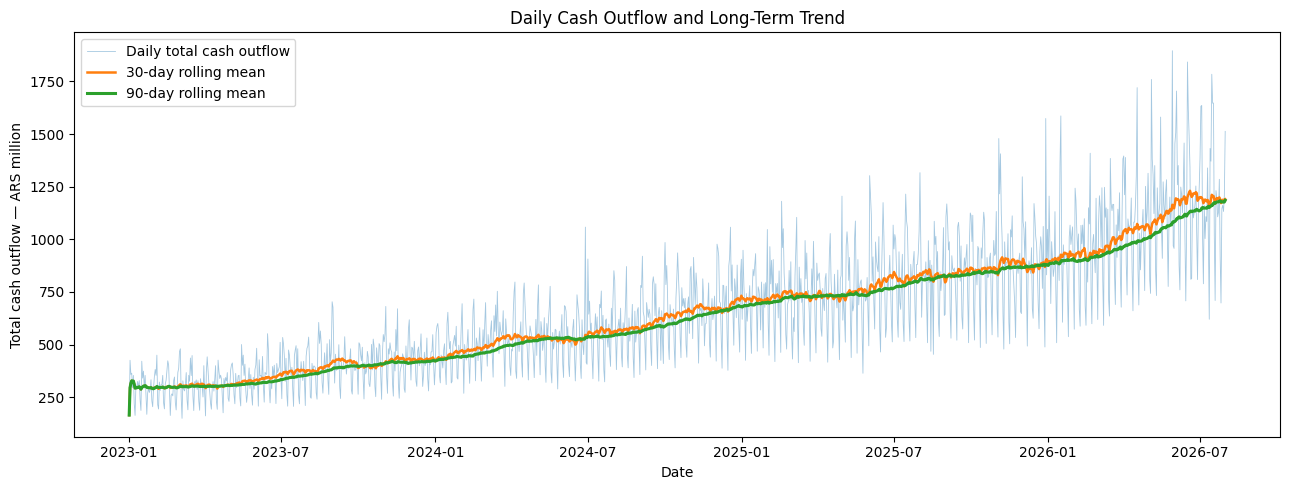

In [75]:
plt.figure(figsize=(13, 5))

plt.plot(
    df["date"],
    df[TARGET],
    linewidth=0.6,
    alpha=0.40,
    label="Daily total cash outflow",
)

plt.plot(
    df["date"],
    df["target_30d_mean"],
    linewidth=1.8,
    label="30-day rolling mean",
)

plt.plot(
    df["date"],
    df["target_90d_mean"],
    linewidth=2.2,
    label="90-day rolling mean",
)

plt.title("Daily Cash Outflow and Long-Term Trend")
plt.xlabel("Date")
plt.ylabel("Total cash outflow — ARS million")
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_daily_cash_outflow_and_long-term_trend.png",
    dpi=300,
    bbox_inches="tight",
)

## Level-Dependent Variability and Log Transformation

The temporal visualization suggests that the absolute variability of
`total_cash_outflow` increases as the series level grows.

This behavior may indicate a partially multiplicative structure, where
seasonal fluctuations and random variation are proportional to the current
cash-outflow level.

This section evaluates:

- The relationship between rolling mean and rolling standard deviation.
- The rolling coefficient of variation.
- Whether a logarithmic transformation stabilizes the variance.
- The consistency of relative variability across years.

Because the target contains only positive values, the natural logarithm can
be applied directly:

$$
y_t^{(\log)} = \log(y_t)
$$

The transformation decision will not be based only on visual appearance.
It will also consider rolling variability, interpretability, model
requirements, and later residual diagnostics.

In [76]:
# ---------------------------------------------------------
# Original-scale and log-scale variability
# ---------------------------------------------------------

df["log_target"] = np.log(df[TARGET])

df["log_target_30d_mean"] = (
    df["log_target"]
    .rolling(window=30, min_periods=7)
    .mean()
)

df["log_target_30d_std"] = (
    df["log_target"]
    .rolling(window=30, min_periods=7)
    .std()
)

df["target_30d_cv"] = (
    df["target_30d_std"]
    / df["target_30d_mean"]
)


# ---------------------------------------------------------
# Annual variability summary
# ---------------------------------------------------------

annual_variability_summary = (
    df.groupby("year")
    .agg(
        observations=(TARGET, "count"),
        target_mean=(TARGET, "mean"),
        target_std=(TARGET, "std"),
        log_target_mean=("log_target", "mean"),
        log_target_std=("log_target", "std"),
    )
)

annual_variability_summary["coefficient_of_variation"] = (
    annual_variability_summary["target_std"]
    / annual_variability_summary["target_mean"]
)

annual_variability_summary = (
    annual_variability_summary[
        [
            "observations",
            "target_mean",
            "target_std",
            "coefficient_of_variation",
            "log_target_mean",
            "log_target_std",
        ]
    ]
    .round(3)
)

annual_variability_summary

,observations,target_mean,target_std,coefficient_of_variation,log_target_mean,log_target_std
year,,,,,,
2023,365,363.469,101.084,0.278,5.855,0.291
2024,366,576.076,153.290,0.266,6.320,0.271
2025,365,804.061,203.588,0.253,6.656,0.264
2026,212,1071.264,269.318,0.251,6.944,0.258


In [77]:
# Use only rows with complete 30-day rolling statistics
rolling_variability_data = df[
    [
        "target_30d_mean",
        "target_30d_std",
        "target_30d_cv",
        "log_target_30d_mean",
        "log_target_30d_std",
    ]
].dropna()

raw_rolling_mean_std_correlation = (
    rolling_variability_data[
        [
            "target_30d_mean",
            "target_30d_std",
        ]
    ]
    .corr()
    .iloc[0, 1]
)

log_rolling_mean_std_correlation = (
    rolling_variability_data[
        [
            "log_target_30d_mean",
            "log_target_30d_std",
        ]
    ]
    .corr()
    .iloc[0, 1]
)

raw_std_series = (
    rolling_variability_data["target_30d_std"]
)

log_std_series = (
    rolling_variability_data["log_target_30d_std"]
)

comparison_window = 90

variability_relationship_checks = pd.Series(
    {
        "raw_rolling_mean_std_correlation": round(
            raw_rolling_mean_std_correlation,
            3,
        ),

        "log_rolling_mean_std_correlation": round(
            log_rolling_mean_std_correlation,
            3,
        ),

        "median_30d_coefficient_of_variation": round(
            rolling_variability_data[
                "target_30d_cv"
            ].median(),
            3,
        ),

        "p05_30d_coefficient_of_variation": round(
            rolling_variability_data[
                "target_30d_cv"
            ].quantile(0.05),
            3,
        ),

        "p95_30d_coefficient_of_variation": round(
            rolling_variability_data[
                "target_30d_cv"
            ].quantile(0.95),
            3,
        ),

        "raw_std_last_to_first_ratio": round(
            raw_std_series.tail(comparison_window).mean()
            / raw_std_series.head(comparison_window).mean(),
            3,
        ),

        "log_std_last_to_first_ratio": round(
            log_std_series.tail(comparison_window).mean()
            / log_std_series.head(comparison_window).mean(),
            3,
        ),
    },
    name="value",
).rename_axis("check").reset_index()

variability_relationship_checks

,check,value
0,raw_rolling_mean_std_correlation,0.967
1,log_rolling_mean_std_correlation,-0.159
2,median_30d_coefficient_of_variation,0.238
3,p05_30d_coefficient_of_variation,0.198
4,p95_30d_coefficient_of_variation,0.283
5,raw_std_last_to_first_ratio,3.537
6,log_std_last_to_first_ratio,0.860


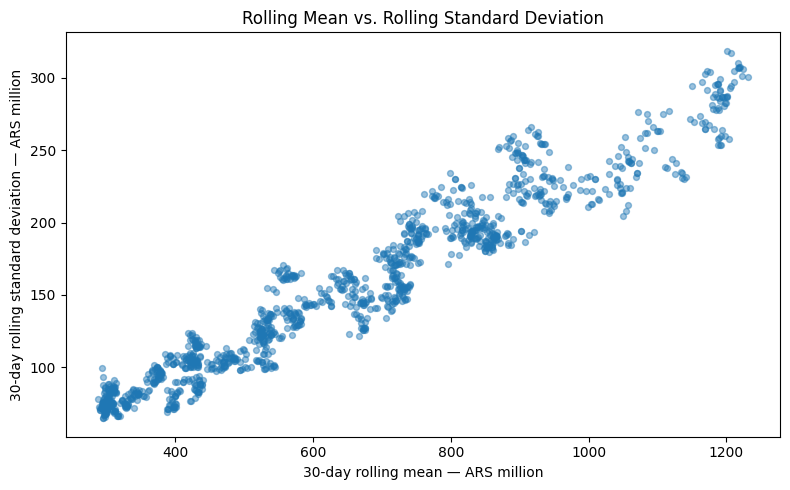

In [78]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rolling_variability_data["target_30d_mean"],
    rolling_variability_data["target_30d_std"],
    alpha=0.45,
    s=18,
)

plt.title("Rolling Mean vs. Rolling Standard Deviation")
plt.xlabel("30-day rolling mean — ARS million")
plt.ylabel("30-day rolling standard deviation — ARS million")
plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_rolling_mean_vs_rolling_standard_deviation.png",
    dpi=300,
    bbox_inches="tight",
)

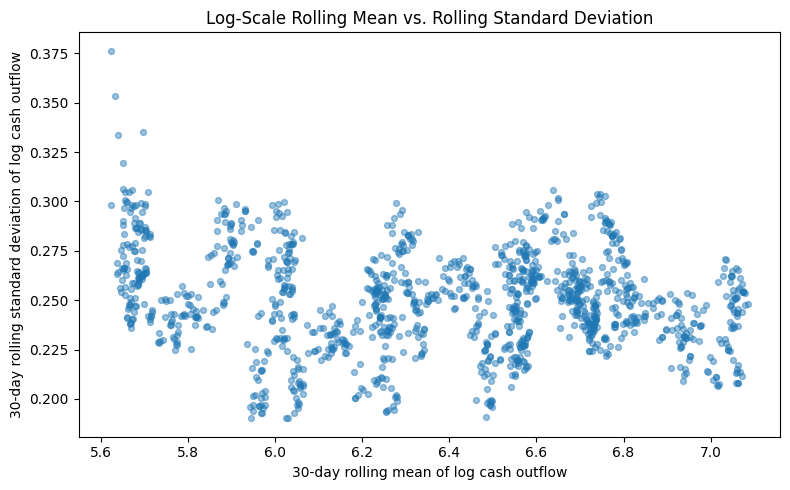

In [79]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rolling_variability_data["log_target_30d_mean"],
    rolling_variability_data["log_target_30d_std"],
    alpha=0.45,
    s=18,
)

plt.title("Log-Scale Rolling Mean vs. Rolling Standard Deviation")
plt.xlabel("30-day rolling mean of log cash outflow")
plt.ylabel("30-day rolling standard deviation of log cash outflow")
plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_log-scale_rolling_mean_vs_rolling_standard_deviation.png",
    dpi=300,
    bbox_inches="tight",
)

### Transformation Decision

The original target exhibits strong level-dependent variability:

- The correlation between the 30-day rolling mean and rolling standard
  deviation is 0.967.
- The rolling standard deviation increases by a factor of 3.537 between the
  beginning and the end of the series.
- Annual coefficients of variation remain relatively stable, ranging from
  0.251 to 0.278.

After applying the natural logarithm:

- The rolling mean–standard-deviation correlation decreases to -0.159.
- The final-to-initial rolling standard-deviation ratio decreases to 0.860.
- The strong upward variance pattern observed in the original scale largely
  disappears.

These results support a partially multiplicative time-series structure.

`log_target` will therefore be used as the preferred working scale for STL,
ACF, PACF, and stationarity diagnostics. The original scale will be preserved
for business interpretation, model evaluation, reserve calculations, and
final reporting.

The final transformation used by each forecasting model will still be
validated through rolling-origin backtesting.

## Weekly Seasonality

Daily Fintech activity may vary systematically across the week because user
behavior, payment schedules, business operations, and weekend activity are
not evenly distributed.

Directly comparing daily cash-outflow levels by weekday would be misleading
because the series has a strong upward trend. Therefore, each observation is
normalized by its trailing 30-day mean:

$$
\text{relative\_cash\_outflow}_t
=
\frac{
\text{total\_cash\_outflow}_t
}{
\text{30-day trailing mean}_t
}
$$

A value above 1 indicates that cash outflow is higher than its recent local
level, while a value below 1 indicates lower-than-usual activity.

This section evaluates:

- Mean and median relative cash outflow by day of week.
- The magnitude of weekend reductions.
- The stability and dispersion of the weekly pattern.
- Whether a seven-day seasonal benchmark is justified.

In [80]:
# Normalize the target by its recent local level

df["target_relative_to_30d_mean"] = (
    df[TARGET]
    / df["target_30d_mean"]
)

df["log_target_deviation_from_30d_mean"] = (
    df["log_target"]
    - df["log_target_30d_mean"]
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_seasonality_summary = (
    df.groupby("day_name")
    .agg(
        observations=(TARGET, "count"),
        mean_cash_outflow=(TARGET, "mean"),
        median_cash_outflow=(TARGET, "median"),
        mean_relative_to_trend=(
            "target_relative_to_30d_mean",
            "mean",
        ),
        median_relative_to_trend=(
            "target_relative_to_30d_mean",
            "median",
        ),
        relative_standard_deviation=(
            "target_relative_to_30d_mean",
            "std",
        ),
        mean_log_deviation=(
            "log_target_deviation_from_30d_mean",
            "mean",
        ),
    )
    .reindex(weekday_order)
)

weekday_seasonality_summary[
    "mean_effect_pct"
] = (
    weekday_seasonality_summary[
        "mean_relative_to_trend"
    ]
    .sub(1)
    .mul(100)
)

weekday_seasonality_summary[
    "median_effect_pct"
] = (
    weekday_seasonality_summary[
        "median_relative_to_trend"
    ]
    .sub(1)
    .mul(100)
)

weekday_seasonality_summary = (
    weekday_seasonality_summary.round(3)
)

weekday_seasonality_summary

,observations,mean_cash_outflow,median_cash_outflow,mean_relative_to_trend,median_relative_to_trend,relative_standard_deviation,mean_log_deviation,mean_effect_pct,median_effect_pct
day_name,,,,,,,,,
Monday,187,734.801,696.772,1.137,1.098,0.178,0.146,13.663,9.759
Tuesday,187,713.117,680.540,1.090,1.056,0.165,0.103,8.957,5.610
Wednesday,187,721.432,683.071,1.099,1.063,0.170,0.111,9.863,6.345
Thursday,187,711.337,675.408,1.091,1.060,0.163,0.105,9.067,5.996
Friday,187,786.154,753.168,1.198,1.159,0.167,0.201,19.795,15.928
Saturday,186,537.661,527.874,0.827,0.811,0.096,-0.168,-17.336,-18.851
Sunday,187,419.233,406.307,0.659,0.655,0.071,-0.393,-34.096,-34.469


In [81]:
week_type_summary = (
    df.assign(
        week_type=np.where(
            df["is_weekend"].eq(1),
            "Weekend",
            "Weekday",
        )
    )
    .groupby("week_type")
    .agg(
        observations=(TARGET, "count"),
        mean_cash_outflow=(TARGET, "mean"),
        median_cash_outflow=(TARGET, "median"),
        mean_relative_to_trend=(
            "target_relative_to_30d_mean",
            "mean",
        ),
        median_relative_to_trend=(
            "target_relative_to_30d_mean",
            "median",
        ),
    )
    .round(3)
)

weekday_relative_mean = (
    week_type_summary.loc[
        "Weekday",
        "mean_relative_to_trend",
    ]
)

weekend_relative_mean = (
    week_type_summary.loc[
        "Weekend",
        "mean_relative_to_trend",
    ]
)

week_type_summary[
    "relative_to_weekday_mean"
] = (
    week_type_summary["mean_relative_to_trend"]
    / weekday_relative_mean
).round(3)

week_type_summary

,observations,mean_cash_outflow,median_cash_outflow,mean_relative_to_trend,median_relative_to_trend,relative_to_weekday_mean
week_type,,,,,,
Weekday,935,733.368,694.219,1.123,1.093,1.000
Weekend,373,478.288,453.206,0.743,0.730,0.662


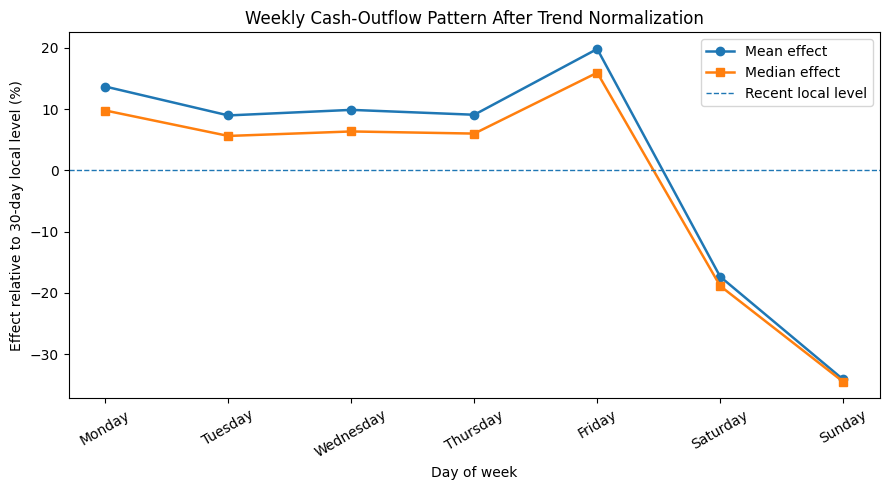

In [82]:
plt.figure(figsize=(9, 5))

plt.plot(
    weekday_seasonality_summary.index,
    weekday_seasonality_summary[
        "mean_effect_pct"
    ],
    marker="o",
    linewidth=1.8,
    label="Mean effect",
)

plt.plot(
    weekday_seasonality_summary.index,
    weekday_seasonality_summary[
        "median_effect_pct"
    ],
    marker="s",
    linewidth=1.8,
    label="Median effect",
)

plt.axhline(
    y=0,
    linewidth=1,
    linestyle="--",
    label="Recent local level",
)

plt.title("Weekly Cash-Outflow Pattern After Trend Normalization")
plt.xlabel("Day of week")
plt.ylabel("Effect relative to 30-day local level (%)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_weekly_cash-outflow-pattern_after_trend_normalization.png",
    dpi=300,
    bbox_inches="tight",
)

### Weekly-Seasonality Findings

The target exhibits a strong and consistent seven-day seasonal pattern.

After normalizing daily cash outflows by their recent 30-day local level:

- Friday is the highest-activity day, with a mean effect of approximately
  **+19.8%**.
- Monday also shows elevated activity, with a mean effect of approximately
  **+13.7%**.
- Saturday is approximately **17.3% below** its recent local level.
- Sunday is approximately **34.1% below** its recent local level.
- Mean and median profiles are similar, indicating that the weekly pattern
  is not driven only by extreme observations.
- Weekend activity is approximately **33.8% lower** than weekday activity
  after local trend normalization.

These results confirm a meaningful weekly seasonal structure and justify using
a **seasonal naive model with a seven-day period** as the primary benchmark in
Notebook 03.

## Payday, Month-End, and Holiday Effects

In addition to weekly seasonality, Fintech cash outflows may respond to
specific calendar conditions:

- Operational paydays.
- The two days following each payday.
- Month-end activity.
- Public holidays.

To avoid attenuating an event effect with the observation being evaluated,
the local target level is calculated using only previous observations:

$$
\text{lagged\_local\_level}_t
=
\frac{1}{30}
\sum_{i=1}^{30} y_{t-i}
$$

The target is then normalized by this lagged level and adjusted for the
baseline day-of-week pattern.

Promotions, system incidents, merchant settlements, and macroeconomic shocks
are excluded from these comparisons to reduce confounding.

In [83]:
# ---------------------------------------------------------
# Lagged local level
# ---------------------------------------------------------

df["target_lagged_30d_mean"] = (
    df[TARGET]
    .shift(1)
    .rolling(
        window=30,
        min_periods=14,
    )
    .mean()
)

df["target_relative_to_lagged_30d_mean"] = (
    df[TARGET]
    / df["target_lagged_30d_mean"]
)


# ---------------------------------------------------------
# Exclude extraordinary business events
# ---------------------------------------------------------

no_extraordinary_event_mask = (
    df["is_promotion"].eq(0)
    & df["system_incident"].eq(0)
    & df["is_large_merchant_settlement"].eq(0)
    & df["is_macro_shock"].eq(0)
)


# ---------------------------------------------------------
# Estimate the regular weekday pattern using clean days
# ---------------------------------------------------------

regular_weekday_mask = (
    no_extraordinary_event_mask
    & df["is_payday_window"].eq(0)
    & df["is_month_end"].eq(0)
    & df["is_holiday"].eq(0)
    & df["target_relative_to_lagged_30d_mean"].notna()
)

weekday_baseline_factor = (
    df.loc[regular_weekday_mask]
    .groupby("day_name")[
        "target_relative_to_lagged_30d_mean"
    ]
    .mean()
    .reindex(weekday_order)
)

df["weekday_baseline_factor"] = (
    df["day_name"]
    .map(weekday_baseline_factor)
)

df["weekday_adjusted_target_ratio"] = (
    df["target_relative_to_lagged_30d_mean"]
    / df["weekday_baseline_factor"]
)

weekday_baseline_factor.round(3)

day_name
Monday       1.088
Tuesday      1.021
Wednesday    0.989
Thursday     1.031
Friday       1.142
Saturday     0.796
Sunday       0.637
Name: target_relative_to_lagged_30d_mean, dtype: float64

In [84]:
# ---------------------------------------------------------
# Masks for isolated calendar effects
# ---------------------------------------------------------

valid_adjusted_ratio = (
    df["weekday_adjusted_target_ratio"].notna()
)

common_clean_mask = (
    no_extraordinary_event_mask
    & valid_adjusted_ratio
)

baseline_mask = (
    common_clean_mask
    & df["is_payday_window"].eq(0)
    & df["is_month_end"].eq(0)
    & df["is_holiday"].eq(0)
)

operational_payday_mask = (
    common_clean_mask
    & df["is_payday"].eq(1)
    & df["is_month_end"].eq(0)
    & df["is_holiday"].eq(0)
)

post_payday_mask = (
    common_clean_mask
    & df["is_payday_window"].eq(1)
    & df["is_payday"].eq(0)
    & df["is_month_end"].eq(0)
    & df["is_holiday"].eq(0)
)

month_end_mask = (
    common_clean_mask
    & df["is_month_end"].eq(1)
    & df["is_payday_window"].eq(0)
    & df["is_holiday"].eq(0)
)

holiday_mask = (
    common_clean_mask
    & df["is_holiday"].eq(1)
    & df["is_payday_window"].eq(0)
    & df["is_month_end"].eq(0)
)


def summarize_calendar_effect(effect_name, mask):
    """
    Summarize a calendar effect after local-trend and weekday adjustment.
    """
    values = (
        df.loc[
            mask,
            "weekday_adjusted_target_ratio",
        ]
        .dropna()
    )

    return {
        "effect": effect_name,
        "number_of_days": int(len(values)),
        "mean_adjusted_ratio": round(
            values.mean(),
            3,
        ),
        "median_adjusted_ratio": round(
            values.median(),
            3,
        ),
        "standard_deviation": round(
            values.std(),
            3,
        ),
        "mean_effect_pct": round(
            (values.mean() - 1) * 100,
            2,
        ),
        "median_effect_pct": round(
            (values.median() - 1) * 100,
            2,
        ),
    }


calendar_effect_summary = pd.DataFrame(
    [
        summarize_calendar_effect(
            "regular_day",
            baseline_mask,
        ),
        summarize_calendar_effect(
            "operational_payday",
            operational_payday_mask,
        ),
        summarize_calendar_effect(
            "post_payday_days_1_2",
            post_payday_mask,
        ),
        summarize_calendar_effect(
            "month_end",
            month_end_mask,
        ),
        summarize_calendar_effect(
            "holiday",
            holiday_mask,
        ),
    ]
)

calendar_effect_summary

,effect,number_of_days,mean_adjusted_ratio,median_adjusted_ratio,standard_deviation,mean_effect_pct,median_effect_pct
0,regular_day,893,1.000,0.999,0.081,0.00,-0.08
1,operational_payday,79,1.281,1.261,0.128,28.12,26.14
2,post_payday_days_1_2,158,1.278,1.269,0.108,27.79,26.89
3,month_end,41,1.178,1.170,0.087,17.75,17.03
4,holiday,64,0.879,0.884,0.059,-12.14,-11.63


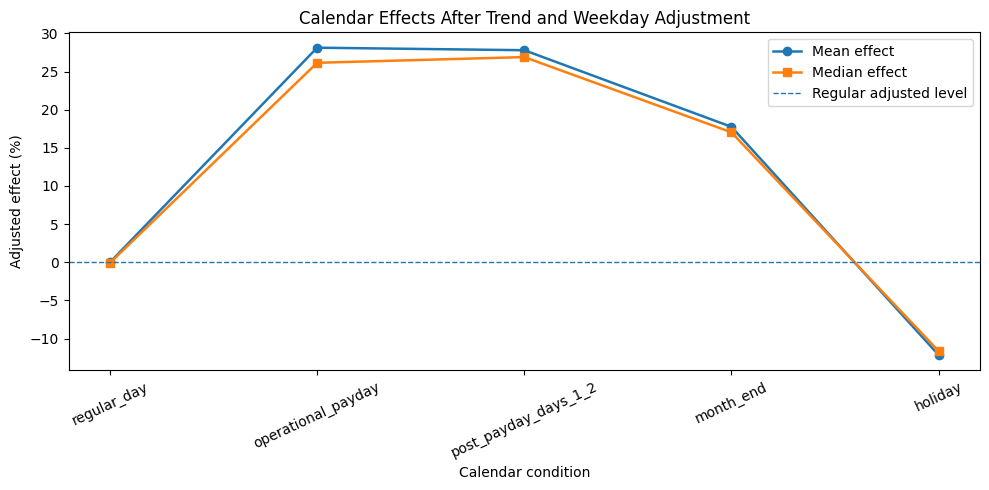

In [85]:
plt.figure(figsize=(10, 5))

plt.plot(
    calendar_effect_summary["effect"],
    calendar_effect_summary["mean_effect_pct"],
    marker="o",
    linewidth=1.8,
    label="Mean effect",
)

plt.plot(
    calendar_effect_summary["effect"],
    calendar_effect_summary["median_effect_pct"],
    marker="s",
    linewidth=1.8,
    label="Median effect",
)

plt.axhline(
    y=0,
    linewidth=1,
    linestyle="--",
    label="Regular adjusted level",
)

plt.title("Calendar Effects After Trend and Weekday Adjustment")
plt.xlabel("Calendar condition")
plt.ylabel("Adjusted effect (%)")
plt.xticks(rotation=25)
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_calendar_effects_after_trend_and_weekday_adjustment.png",
    dpi=300,
    bbox_inches="tight",
)

### Calendar-Effect Findings

After adjusting for the recent local level, regular weekday behavior, and
documented extraordinary events, the target shows clear calendar effects:

- Operational paydays increase daily cash outflows by approximately **28.1%**.
- The two days following a payday increase cash outflows by approximately
  **27.8%**.
- Month-end dates increase cash outflows by approximately **17.8%**.
- Public holidays reduce cash outflows by approximately **12.1%**.

Mean and median effects are similar, indicating that these patterns are not
driven only by a few extreme observations.

The operational payday and the two following days have similar effects because
Notebook 01 defined a common three-day payday window. No additional target
effect was assigned exclusively to the operational payday.

These findings support including payday-window, month-end, and holiday
variables in calendar-aware forecasting models.

## Promotions and Extraordinary Events

The synthetic dataset includes several documented events that may alter daily
cash outflows:

- Promotional campaigns.
- System incidents.
- Exceptional merchant settlements.
- Macroeconomic shocks.

To evaluate these events, the target is adjusted for:

1. Its recent trailing local level.
2. The regular day-of-week pattern.
3. Payday-window effects.
4. Month-end effects.
5. Holiday effects.

The resulting ratio represents cash outflow relative to its expected local,
weekly, and calendar-adjusted level.

Because system incidents, merchant settlements, and macroeconomic shocks have
few observations, their results will be interpreted descriptively rather than
as precise population estimates.

In [86]:
# ---------------------------------------------------------
# Extract the previously estimated calendar effects
# ---------------------------------------------------------

calendar_effect_map = (
    calendar_effect_summary
    .set_index("effect")["mean_adjusted_ratio"]
    .to_dict()
)

required_calendar_effects = [
    "operational_payday",
    "post_payday_days_1_2",
    "month_end",
    "holiday",
]

missing_calendar_effects = [
    effect
    for effect in required_calendar_effects
    if effect not in calendar_effect_map
]

if missing_calendar_effects:
    raise KeyError(
        "The following calendar effects are missing: "
        f"{missing_calendar_effects}"
    )


# ---------------------------------------------------------
# Create a multiplicative calendar-adjustment factor
# ---------------------------------------------------------

df["calendar_adjustment_factor"] = 1.0

operational_payday_mask_all = (
    df["is_payday"].eq(1)
)

post_payday_mask_all = (
    df["is_payday_window"].eq(1)
    & df["is_payday"].eq(0)
)

df.loc[
    operational_payday_mask_all,
    "calendar_adjustment_factor",
] *= calendar_effect_map["operational_payday"]

df.loc[
    post_payday_mask_all,
    "calendar_adjustment_factor",
] *= calendar_effect_map["post_payday_days_1_2"]

df.loc[
    df["is_month_end"].eq(1),
    "calendar_adjustment_factor",
] *= calendar_effect_map["month_end"]

df.loc[
    df["is_holiday"].eq(1),
    "calendar_adjustment_factor",
] *= calendar_effect_map["holiday"]


# Ratio after trend, weekday, and calendar adjustment
df["fully_adjusted_target_ratio"] = (
    df["weekday_adjusted_target_ratio"]
    / df["calendar_adjustment_factor"]
)

df[
    [
        "date",
        TARGET,
        "weekday_adjusted_target_ratio",
        "calendar_adjustment_factor",
        "fully_adjusted_target_ratio",
    ]
].dropna().head()

,date,total_cash_outflow,weekday_adjusted_target_ratio,calendar_adjustment_factor,fully_adjusted_target_ratio
14,2023-01-15,187.160,0.996636,1.000,0.996636
15,2023-01-16,420.830,1.344568,1.281,1.049624
16,2023-01-17,340.758,1.127135,1.278,0.881952
17,2023-01-18,373.676,1.265235,1.278,0.990012
18,2023-01-19,292.736,0.937316,1.000,0.937316


In [87]:
# Validate the calendar-adjusted target ratio

adjusted_ratio_checks = pd.Series(
    {
        "valid_observations": int(
            df["fully_adjusted_target_ratio"]
            .notna()
            .sum()
        ),

        "missing_adjustment_factors": int(
            df["calendar_adjustment_factor"]
            .isna()
            .sum()
        ),

        "non_positive_adjustment_factors": int(
            df["calendar_adjustment_factor"]
            .le(0)
            .sum()
        ),

        "non_positive_adjusted_ratios": int(
            df["fully_adjusted_target_ratio"]
            .dropna()
            .le(0)
            .sum()
        ),

        "median_adjusted_ratio": round(
            df["fully_adjusted_target_ratio"]
            .median(),
            3,
        ),

        "mean_adjusted_ratio": round(
            df["fully_adjusted_target_ratio"]
            .mean(),
            3,
        ),
    },
    name="value",
).rename_axis("check").reset_index()

adjusted_ratio_checks

,check,value
0,valid_observations,1294.000
1,missing_adjustment_factors,0.000
2,non_positive_adjustment_factors,0.000
3,non_positive_adjusted_ratios,0.000
4,median_adjusted_ratio,1.000
5,mean_adjusted_ratio,1.005


In [88]:
# ---------------------------------------------------------
# Identify isolated extraordinary events
# ---------------------------------------------------------

extraordinary_event_flags = [
    "is_promotion",
    "system_incident",
    "is_large_merchant_settlement",
    "is_macro_shock",
]

df["extraordinary_event_count"] = (
    df[extraordinary_event_flags]
    .sum(axis=1)
)

valid_event_ratio_mask = (
    df["fully_adjusted_target_ratio"]
    .notna()
)

no_extraordinary_event_mask = (
    df["extraordinary_event_count"].eq(0)
    & valid_event_ratio_mask
)

event_masks = {
    "regular_adjusted_day": (
        no_extraordinary_event_mask
    ),

    "promotion": (
        df["is_promotion"].eq(1)
        & df["extraordinary_event_count"].eq(1)
        & valid_event_ratio_mask
    ),

    "system_incident": (
        df["system_incident"].eq(1)
        & df["extraordinary_event_count"].eq(1)
        & valid_event_ratio_mask
    ),

    "merchant_settlement": (
        df["is_large_merchant_settlement"].eq(1)
        & df["extraordinary_event_count"].eq(1)
        & valid_event_ratio_mask
    ),

    "macro_shock": (
        df["is_macro_shock"].eq(1)
        & df["extraordinary_event_count"].eq(1)
        & valid_event_ratio_mask
    ),
}

expected_directions = {
    "regular_adjusted_day": "baseline",
    "promotion": "up",
    "system_incident": "down",
    "merchant_settlement": "up",
    "macro_shock": "up",
}


def summarize_extraordinary_event(
    event_name,
    mask,
):
    """
    Summarize target behavior after trend, weekday,
    and calendar adjustment.
    """
    values = (
        df.loc[
            mask,
            "fully_adjusted_target_ratio",
        ]
        .dropna()
    )

    return {
        "event": event_name,
        "expected_direction": expected_directions[event_name],
        "number_of_days": int(len(values)),
        "mean_adjusted_ratio": round(
            values.mean(),
            3,
        ),
        "median_adjusted_ratio": round(
            values.median(),
            3,
        ),
        "standard_deviation": round(
            values.std(),
            3,
        ),
        "minimum_ratio": round(
            values.min(),
            3,
        ),
        "maximum_ratio": round(
            values.max(),
            3,
        ),
        "mean_effect_pct": round(
            (values.mean() - 1) * 100,
            2,
        ),
        "median_effect_pct": round(
            (values.median() - 1) * 100,
            2,
        ),
    }


extraordinary_event_summary = pd.DataFrame(
    [
        summarize_extraordinary_event(
            event_name,
            mask,
        )
        for event_name, mask in event_masks.items()
    ]
)

extraordinary_event_summary

,event,expected_direction,number_of_days,mean_adjusted_ratio,median_adjusted_ratio,standard_deviation,minimum_ratio,maximum_ratio,mean_effect_pct,median_effect_pct
0,regular_adjusted_day,baseline,1242,1.000,0.997,0.082,0.748,1.324,-0.01,-0.29
1,promotion,up,36,1.148,1.149,0.090,0.936,1.366,14.84,14.86
2,system_incident,down,7,0.743,0.767,0.120,0.532,0.919,-25.72,-23.27
3,merchant_settlement,up,5,1.544,1.459,0.157,1.411,1.757,54.44,45.90
4,macro_shock,up,4,1.203,1.246,0.104,1.049,1.272,20.32,24.56


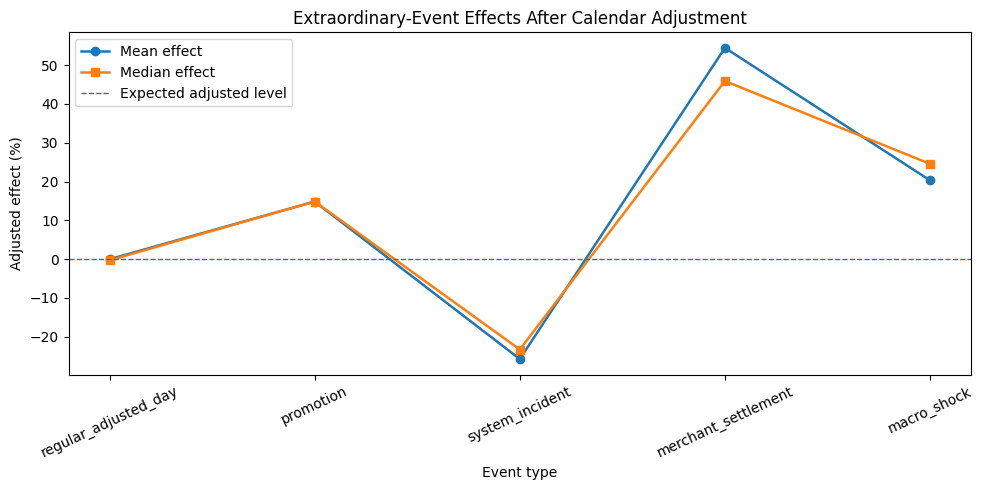

In [90]:
plt.figure(figsize=(10, 5))

plt.plot(
    extraordinary_event_summary["event"],
    extraordinary_event_summary["mean_effect_pct"],
    marker="o",
    linewidth=1.8,
    label="Mean effect",
)

plt.plot(
    extraordinary_event_summary["event"],
    extraordinary_event_summary["median_effect_pct"],
    marker="s",
    linewidth=1.8,
    label="Median effect",
)

plt.axhline(
    y=0,
    linewidth=1,
    linestyle="--",
    label="Expected adjusted level",
)

plt.title("Extraordinary-Event Effects After Calendar Adjustment")
plt.xlabel("Event type")
plt.ylabel("Adjusted effect (%)")
plt.xticks(rotation=25)
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_extraordinary-event_effects_after_calendar_adjustment.png",
    dpi=300,
    bbox_inches="tight",
)

### Extraordinary-Event Findings

After adjusting the target for its recent local level, weekly seasonality,
payday effects, month-end effects, and holidays:

- Promotional campaigns increase daily cash outflows by approximately
  **14.8%**.
- System incidents reduce cash outflows by approximately **25.7%**.
- Exceptional merchant settlements increase cash outflows by approximately
  **54.4%**.
- Macroeconomic shocks increase cash outflows by approximately **20.3%**.

The overall adjusted ratio has a mean of 1.005 and a median of 1.000,
indicating that the adjustment procedure does not introduce a meaningful
global bias.

Mean and median event effects have the expected direction. However, system
incidents, merchant settlements, and macroeconomic shocks contain only 7, 5,
and 4 observations, respectively. Their estimated magnitudes should therefore
be interpreted descriptively rather than as precise population effects.

## Extreme Observations and Documented Causes

Extreme observations are examined from two complementary perspectives:

1. **Raw target extremes:** unusually high or low daily cash-outflow values
   in the original ARS-million scale.
2. **Adjusted extremes:** observations that remain unusual after accounting
   for local trend, weekly seasonality, payday effects, month-end effects,
   and holidays.

The 1st and 99th percentiles of `fully_adjusted_target_ratio` are used as
descriptive thresholds:

$$
\text{low extreme}
\quad \text{if} \quad
r_t \leq Q_{0.01}(r)
$$

$$
\text{high extreme}
\quad \text{if} \quad
r_t \geq Q_{0.99}(r)
$$

These thresholds are used for exploratory review, not as an automatic rule
for deleting observations. Documented events and operational causes will be
preserved for later forecasting and stress analysis.

In [91]:
# Create traceable descriptions of the known calendar and event conditions

def build_documented_cause(row):
    """
    Combine all known calendar and extraordinary-event conditions
    associated with one daily observation.
    """
    causes = []

    if row["is_payday"] == 1:
        causes.append("operational_payday")
    elif row["is_payday_window"] == 1:
        causes.append("post_payday_window")

    if row["is_month_end"] == 1:
        causes.append("month_end")

    if row["is_holiday"] == 1:
        causes.append("holiday")

    if row["is_promotion"] == 1:
        causes.append("promotion")

    if row["system_incident"] == 1:
        causes.append("system_incident")

    if row["is_large_merchant_settlement"] == 1:
        causes.append("merchant_settlement")

    if row["is_macro_shock"] == 1:
        causes.append("macro_shock")

    if not causes:
        return "no_documented_event"

    return " + ".join(causes)


df["documented_cause"] = df.apply(
    build_documented_cause,
    axis=1,
)

df[
    [
        "date",
        TARGET,
        "fully_adjusted_target_ratio",
        "documented_cause",
    ]
].dropna().head()

,date,total_cash_outflow,fully_adjusted_target_ratio,documented_cause
14,2023-01-15,187.160,0.996636,no_documented_event
15,2023-01-16,420.830,1.049624,operational_payday
16,2023-01-17,340.758,0.881952,post_payday_window
17,2023-01-18,373.676,0.990012,post_payday_window
18,2023-01-19,292.736,0.937316,no_documented_event


In [92]:
valid_adjusted_values = (
    df["fully_adjusted_target_ratio"]
    .dropna()
)

lower_extreme_threshold = (
    valid_adjusted_values.quantile(0.01)
)

upper_extreme_threshold = (
    valid_adjusted_values.quantile(0.99)
)

df["adjusted_extreme_type"] = "not_extreme"

df.loc[
    df["fully_adjusted_target_ratio"]
    .le(lower_extreme_threshold),
    "adjusted_extreme_type",
] = "low_extreme"

df.loc[
    df["fully_adjusted_target_ratio"]
    .ge(upper_extreme_threshold),
    "adjusted_extreme_type",
] = "high_extreme"


extreme_observations = (
    df.loc[
        df["adjusted_extreme_type"].ne(
            "not_extreme"
        ),
        [
            "date",
            TARGET,
            "fully_adjusted_target_ratio",
            "adjusted_extreme_type",
            "documented_cause",
            "is_payday_window",
            "is_month_end",
            "is_holiday",
            "is_promotion",
            "system_incident",
            "is_large_merchant_settlement",
            "is_macro_shock",
        ],
    ]
    .sort_values(
        [
            "adjusted_extreme_type",
            "fully_adjusted_target_ratio",
        ]
    )
    .reset_index(drop=True)
)

print(
    f"Lower threshold: {lower_extreme_threshold:.3f}"
)

print(
    f"Upper threshold: {upper_extreme_threshold:.3f}"
)

extreme_observations

Lower threshold: 0.824
Upper threshold: 1.240


,date,total_cash_outflow,fully_adjusted_target_ratio,adjusted_extreme_type,documented_cause,is_payday_window,is_month_end,is_holiday,is_promotion,system_incident,is_large_merchant_settlement,is_macro_shock
0,2023-08-14,499.330,1.252679,high_extreme,macro_shock,0,0,0,0,0,0,1
1,2025-11-05,1406.347,1.264487,high_extreme,post_payday_window + promotion,1,0,0,1,0,0,0
2,2024-09-04,919.777,1.266854,high_extreme,post_payday_window,1,0,0,0,0,0,0
3,2025-06-02,1302.578,1.272185,high_extreme,operational_payday + macro_shock,1,0,0,0,0,0,1
4,2025-11-03,1478.877,1.279054,high_extreme,operational_payday + promotion,1,0,0,1,0,0,0
5,2024-11-04,914.027,1.299983,high_extreme,promotion,0,0,0,1,0,0,0
6,2025-03-27,990.656,1.323631,high_extreme,no_documented_event,0,0,0,0,0,0,0
7,2024-03-13,688.153,1.365945,high_extreme,promotion,0,0,0,1,0,0,0
8,2023-08-31,703.331,1.411442,high_extreme,month_end + merchant_settlement,0,1,0,0,0,1,0
9,2025-04-30,1205.013,1.428745,high_extreme,month_end + merchant_settlement,0,1,0,0,0,1,0


In [93]:
extreme_documentation_summary = (
    extreme_observations
    .assign(
        has_documented_cause=lambda data: (
            data["documented_cause"]
            .ne("no_documented_event")
        )
    )
    .groupby("adjusted_extreme_type")
    .agg(
        number_of_extremes=(
            "date",
            "count",
        ),
        documented_extremes=(
            "has_documented_cause",
            "sum",
        ),
        minimum_adjusted_ratio=(
            "fully_adjusted_target_ratio",
            "min",
        ),
        median_adjusted_ratio=(
            "fully_adjusted_target_ratio",
            "median",
        ),
        maximum_adjusted_ratio=(
            "fully_adjusted_target_ratio",
            "max",
        ),
    )
    .reset_index()
)

extreme_documentation_summary[
    "documented_share"
] = (
    extreme_documentation_summary[
        "documented_extremes"
    ]
    / extreme_documentation_summary[
        "number_of_extremes"
    ]
)

extreme_documentation_summary = (
    extreme_documentation_summary.round(3)
)

extreme_documentation_summary

,adjusted_extreme_type,number_of_extremes,documented_extremes,minimum_adjusted_ratio,median_adjusted_ratio,maximum_adjusted_ratio,documented_share
0,high_extreme,13,12,1.253,1.324,1.757,0.923
1,low_extreme,13,9,0.532,0.772,0.819,0.692


In [94]:
extreme_cause_summary = (
    extreme_observations
    .groupby(
        [
            "adjusted_extreme_type",
            "documented_cause",
        ]
    )
    .size()
    .rename("number_of_days")
    .reset_index()
    .sort_values(
        [
            "adjusted_extreme_type",
            "number_of_days",
        ],
        ascending=[True, False],
    )
)

extreme_cause_summary

,adjusted_extreme_type,documented_cause,number_of_days
1,high_extreme,merchant_settlement,3
2,high_extreme,month_end + merchant_settlement,2
8,high_extreme,promotion,2
0,high_extreme,macro_shock,1
3,high_extreme,no_documented_event,1
4,high_extreme,operational_payday + macro_shock,1
5,high_extreme,operational_payday + promotion,1
6,high_extreme,post_payday_window,1
7,high_extreme,post_payday_window + promotion,1
13,low_extreme,system_incident,5


In [95]:
highest_raw_outflows = (
    df.nlargest(
        10,
        TARGET,
    )[
        [
            "date",
            TARGET,
            "fully_adjusted_target_ratio",
            "documented_cause",
        ]
    ]
    .reset_index(drop=True)
)

lowest_raw_outflows = (
    df.nsmallest(
        10,
        TARGET,
    )[
        [
            "date",
            TARGET,
            "fully_adjusted_target_ratio",
            "documented_cause",
        ]
    ]
    .reset_index(drop=True)
)

print("Highest raw cash-outflow observations:")
display(highest_raw_outflows)

print("Lowest raw cash-outflow observations:")
display(lowest_raw_outflows)

Highest raw cash-outflow observations:


,date,total_cash_outflow,fully_adjusted_target_ratio,documented_cause
0,2026-05-29,1896.155,1.458963,merchant_settlement
1,2026-06-16,1842.679,1.204930,operational_payday
2,2026-07-15,1784.235,1.186984,operational_payday + promotion
3,2026-05-04,1759.598,1.232970,operational_payday
4,2026-04-17,1720.687,1.119191,post_payday_window
5,2026-06-03,1704.545,1.129421,post_payday_window
6,2026-07-17,1647.712,0.937335,post_payday_window
7,2026-07-16,1646.676,1.031389,post_payday_window
8,2026-07-03,1636.256,0.934094,post_payday_window
9,2026-07-02,1632.026,1.034964,post_payday_window


Lowest raw cash-outflow observations:


,date,total_cash_outflow,fully_adjusted_target_ratio,documented_cause
0,2023-03-05,149.450,0.762138,no_documented_event
1,2023-04-02,161.093,0.947554,holiday
2,2023-02-19,163.175,0.852320,no_documented_event
3,2023-01-08,163.287,NaN,no_documented_event
4,2023-01-01,164.867,NaN,holiday
5,2023-01-22,168.452,0.874031,no_documented_event
6,2023-04-23,175.897,0.909864,no_documented_event
7,2023-03-19,186.430,0.948487,no_documented_event
8,2023-01-15,187.160,0.996636,no_documented_event
9,2023-03-26,187.856,0.950173,no_documented_event


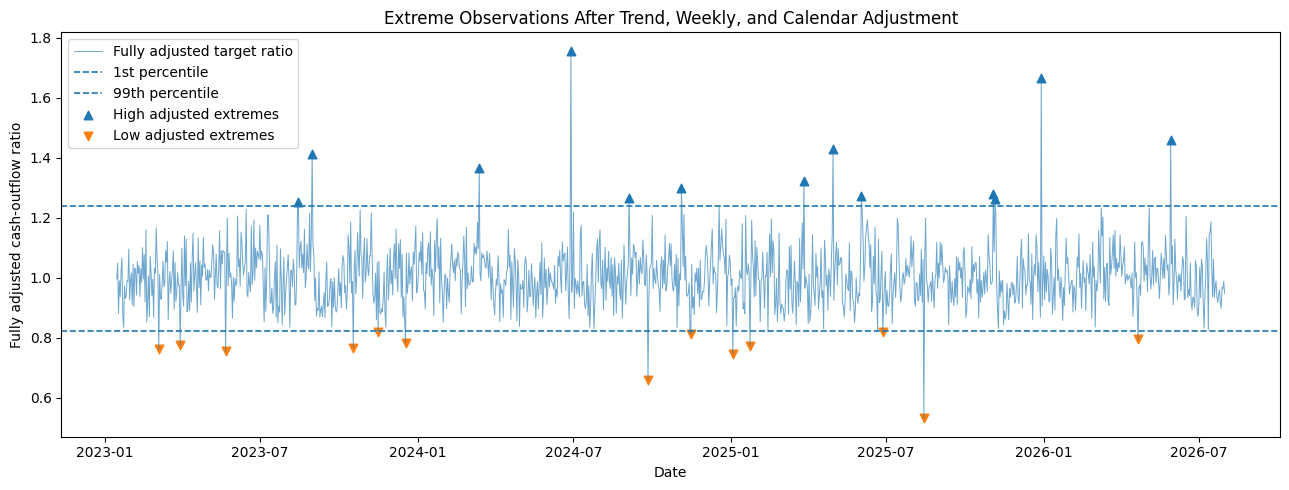

In [96]:
plt.figure(figsize=(13, 5))

plt.plot(
    df["date"],
    df["fully_adjusted_target_ratio"],
    linewidth=0.7,
    alpha=0.65,
    label="Fully adjusted target ratio",
)

plt.axhline(
    y=lower_extreme_threshold,
    linestyle="--",
    linewidth=1.2,
    label="1st percentile",
)

plt.axhline(
    y=upper_extreme_threshold,
    linestyle="--",
    linewidth=1.2,
    label="99th percentile",
)

high_extremes = df[
    df["adjusted_extreme_type"]
    .eq("high_extreme")
]

low_extremes = df[
    df["adjusted_extreme_type"]
    .eq("low_extreme")
]

plt.scatter(
    high_extremes["date"],
    high_extremes[
        "fully_adjusted_target_ratio"
    ],
    s=38,
    marker="^",
    label="High adjusted extremes",
)

plt.scatter(
    low_extremes["date"],
    low_extremes[
        "fully_adjusted_target_ratio"
    ],
    s=38,
    marker="v",
    label="Low adjusted extremes",
)

plt.title(
    "Extreme Observations After Trend, Weekly, and Calendar Adjustment"
)
plt.xlabel("Date")
plt.ylabel("Fully adjusted cash-outflow ratio")
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_extreme_observations_after_trend_weekly_and_calendar_adjustment.png",
    dpi=300,
    bbox_inches="tight",
)

### Extreme-Observation Findings

Using the 1st and 99th percentiles of the fully adjusted target ratio, the
analysis identified 13 high extremes and 13 low extremes.

- **12 of the 13 high extremes (92.3%)** have a documented calendar or
  extraordinary-event cause.
- **9 of the 13 low extremes (69.2%)** have a documented cause.
- Exceptional merchant settlements are the main source of adjusted high
  extremes.
- System incidents are the main source of adjusted low extremes.
- One high extreme and four low extremes do not have a documented event and
  are interpreted as stochastic variation generated by the synthetic process.

The largest raw cash-outflow observations are concentrated near the end of
the series because the structural level increases over time. Conversely, the
smallest raw observations occur mainly near the beginning of the dataset.
Therefore, raw magnitude alone is not sufficient to classify an observation
as anomalous.

No observations will be removed. Documented events will be preserved as valid
business conditions, while unexplained adjusted extremes will remain part of
the uncertainty that forecasting models must represent.

## STL Decomposition

The logarithmic target is decomposed into three additive components:

$$
\log(y_t)
=
T_t
+
S_t
+
R_t
$$

where:

- $T_t$ is the long-term trend component.
- $S_t$ is the weekly seasonal component.
- $R_t$ is the remainder component.

Because the decomposition is performed on the logarithmic scale, it
corresponds approximately to a multiplicative decomposition on the original
cash-outflow scale.

A weekly period of seven days is used. The robust STL option is enabled to
reduce the influence of occasional extreme observations on the estimated
trend and seasonal components.

The decomposition is used for exploratory diagnosis. It does not use future
information to construct forecasting features or evaluate predictive models.

In [97]:
import statsmodels
from statsmodels.tsa.seasonal import STL

print(f"statsmodels version: {statsmodels.__version__}")


# Build a daily pandas Series with an explicit DateTimeIndex
log_target_series = (
    df.set_index("date")["log_target"]
    .sort_index()
    .asfreq("D")
)

assert log_target_series.index.is_monotonic_increasing, (
    "The time index is not ordered."
)

assert log_target_series.isna().sum() == 0, (
    "Missing observations were detected in the log-target series."
)

assert len(log_target_series) == len(df), (
    "The STL input does not contain the expected number of observations."
)

log_target_series.head()

statsmodels version: 0.14.6


date
2023-01-01    5.105139
2023-01-02    6.052804
2023-01-03    5.880863
2023-01-04    5.897316
2023-01-05    5.686857
Freq: D, Name: log_target, dtype: float64

In [98]:
# Robust weekly STL decomposition on the logarithmic target

stl_model = STL(
    log_target_series,
    period=7,
    seasonal=13,
    trend=91,
    robust=True,
)

stl_result = stl_model.fit()

df["stl_log_trend"] = (
    stl_result.trend.to_numpy()
)

df["stl_log_seasonal"] = (
    stl_result.seasonal.to_numpy()
)

df["stl_log_remainder"] = (
    stl_result.resid.to_numpy()
)

df[
    [
        "date",
        "log_target",
        "stl_log_trend",
        "stl_log_seasonal",
        "stl_log_remainder",
    ]
].head()

,date,log_target,stl_log_trend,stl_log_seasonal,stl_log_remainder
0,2023-01-01,5.105139,5.656019,-0.515001,-0.035878
1,2023-01-02,6.052804,5.656268,0.233127,0.163410
2,2023-01-03,5.880863,5.656521,0.142215,0.082126
3,2023-01-04,5.897316,5.656779,0.196808,0.043729
4,2023-01-05,5.686857,5.657040,0.011872,0.017945


In [99]:
# ---------------------------------------------------------
# Reconstruction check
# ---------------------------------------------------------

stl_reconstructed_log_target = (
    df["stl_log_trend"]
    + df["stl_log_seasonal"]
    + df["stl_log_remainder"]
)

stl_reconstruction_error = (
    df["log_target"]
    - stl_reconstructed_log_target
)


# ---------------------------------------------------------
# Trend and seasonal strength
# ---------------------------------------------------------

remainder_variance = (
    df["stl_log_remainder"].var()
)

trend_plus_remainder_variance = (
    (
        df["stl_log_trend"]
        + df["stl_log_remainder"]
    )
    .var()
)

seasonal_plus_remainder_variance = (
    (
        df["stl_log_seasonal"]
        + df["stl_log_remainder"]
    )
    .var()
)

trend_strength = max(
    0.0,
    1
    - remainder_variance
    / trend_plus_remainder_variance,
)

seasonal_strength = max(
    0.0,
    1
    - remainder_variance
    / seasonal_plus_remainder_variance,
)


stl_checks = pd.Series(
    {
        "number_of_observations": len(df),

        "missing_trend_values": int(
            df["stl_log_trend"].isna().sum()
        ),

        "missing_seasonal_values": int(
            df["stl_log_seasonal"].isna().sum()
        ),

        "missing_remainder_values": int(
            df["stl_log_remainder"].isna().sum()
        ),

        "maximum_reconstruction_error": round(
            stl_reconstruction_error
            .abs()
            .max(),
            10,
        ),

        "trend_strength": round(
            trend_strength,
            3,
        ),

        "weekly_seasonal_strength": round(
            seasonal_strength,
            3,
        ),

        "remainder_mean": round(
            df["stl_log_remainder"].mean(),
            4,
        ),

        "remainder_standard_deviation": round(
            df["stl_log_remainder"].std(),
            4,
        ),

        "remainder_p01": round(
            df["stl_log_remainder"]
            .quantile(0.01),
            4,
        ),

        "remainder_p99": round(
            df["stl_log_remainder"]
            .quantile(0.99),
            4,
        ),
    },
    name="value",
).rename_axis("check").reset_index()

stl_checks

,check,value
0,number_of_observations,1308.0000
1,missing_trend_values,0.0000
2,missing_seasonal_values,0.0000
3,missing_remainder_values,0.0000
4,maximum_reconstruction_error,0.0000
5,trend_strength,0.9080
6,weekly_seasonal_strength,0.7300
7,remainder_mean,0.0144
8,remainder_standard_deviation,0.1285
9,remainder_p01,-0.2482


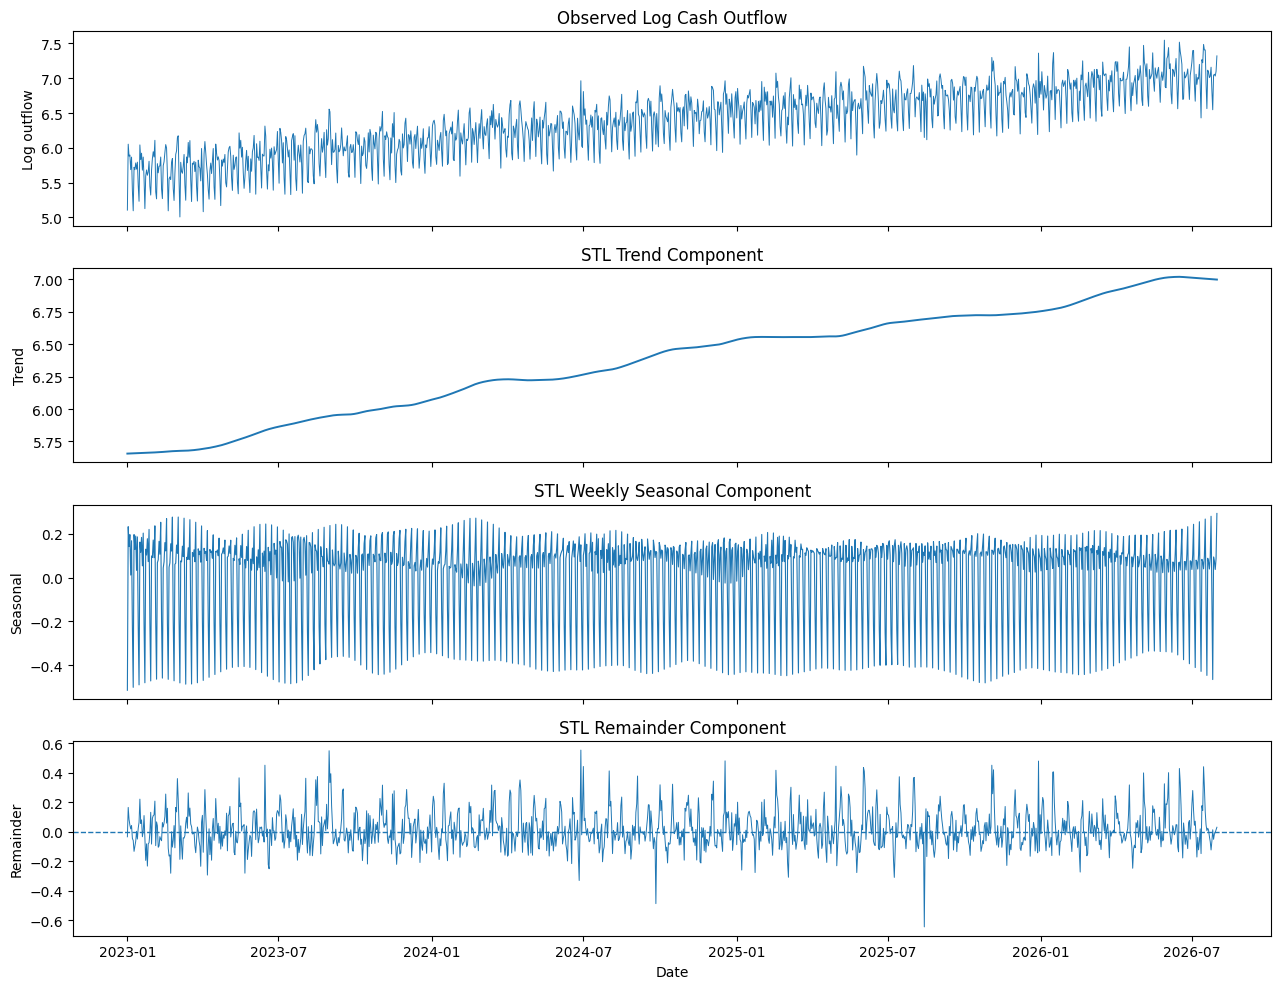

In [100]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(13, 10),
    sharex=True,
)

axes[0].plot(
    df["date"],
    df["log_target"],
    linewidth=0.7,
)
axes[0].set_title("Observed Log Cash Outflow")
axes[0].set_ylabel("Log outflow")

axes[1].plot(
    df["date"],
    df["stl_log_trend"],
    linewidth=1.4,
)
axes[1].set_title("STL Trend Component")
axes[1].set_ylabel("Trend")

axes[2].plot(
    df["date"],
    df["stl_log_seasonal"],
    linewidth=0.8,
)
axes[2].set_title("STL Weekly Seasonal Component")
axes[2].set_ylabel("Seasonal")

axes[3].plot(
    df["date"],
    df["stl_log_remainder"],
    linewidth=0.7,
)
axes[3].axhline(
    y=0,
    linewidth=1,
    linestyle="--",
)
axes[3].set_title("STL Remainder Component")
axes[3].set_xlabel("Date")
axes[3].set_ylabel("Remainder")

fig.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_STL_remainder_component.png",
    dpi=300,
    bbox_inches="tight",
)

In [101]:
stl_weekday_profile = (
    df.groupby("day_name")
    .agg(
        observations=(
            "stl_log_seasonal",
            "count",
        ),
        mean_log_seasonal_component=(
            "stl_log_seasonal",
            "mean",
        ),
        median_log_seasonal_component=(
            "stl_log_seasonal",
            "median",
        ),
        standard_deviation=(
            "stl_log_seasonal",
            "std",
        ),
    )
    .reindex(weekday_order)
)

stl_weekday_profile[
    "mean_multiplicative_effect_pct"
] = (
    np.exp(
        stl_weekday_profile[
            "mean_log_seasonal_component"
        ]
    )
    .sub(1)
    .mul(100)
)

stl_weekday_profile[
    "median_multiplicative_effect_pct"
] = (
    np.exp(
        stl_weekday_profile[
            "median_log_seasonal_component"
        ]
    )
    .sub(1)
    .mul(100)
)

stl_weekday_profile = (
    stl_weekday_profile.round(3)
)

stl_weekday_profile

,observations,mean_log_seasonal_component,median_log_seasonal_component,standard_deviation,mean_multiplicative_effect_pct,median_multiplicative_effect_pct
day_name,,,,,,
Monday,187,0.117,0.118,0.034,12.449,12.574
Tuesday,187,0.095,0.095,0.034,10.009,10.008
Wednesday,187,0.095,0.102,0.055,9.927,10.750
Thursday,187,0.095,0.102,0.043,9.998,10.777
Friday,187,0.192,0.194,0.041,21.200,21.429
Saturday,186,-0.176,-0.181,0.036,-16.149,-16.597
Sunday,187,-0.418,-0.421,0.037,-34.191,-34.330


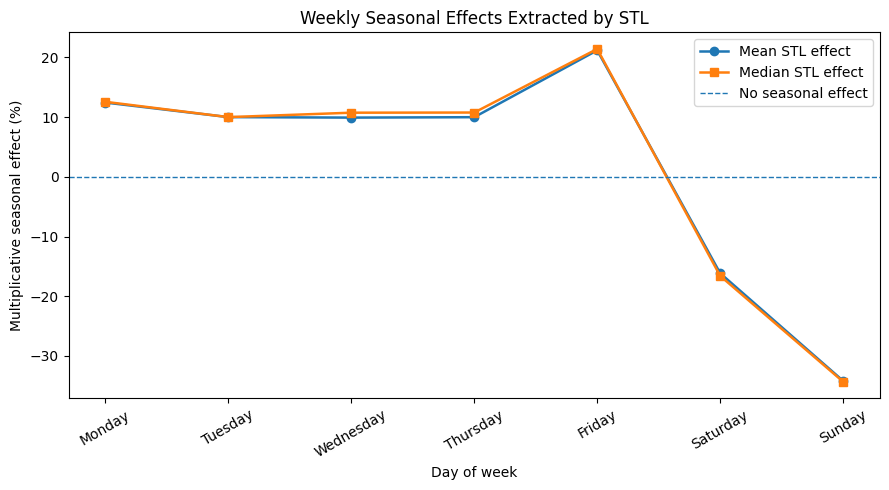

In [102]:
plt.figure(figsize=(9, 5))

plt.plot(
    stl_weekday_profile.index,
    stl_weekday_profile[
        "mean_multiplicative_effect_pct"
    ],
    marker="o",
    linewidth=1.8,
    label="Mean STL effect",
)

plt.plot(
    stl_weekday_profile.index,
    stl_weekday_profile[
        "median_multiplicative_effect_pct"
    ],
    marker="s",
    linewidth=1.8,
    label="Median STL effect",
)

plt.axhline(
    y=0,
    linewidth=1,
    linestyle="--",
    label="No seasonal effect",
)

plt.title("Weekly Seasonal Effects Extracted by STL")
plt.xlabel("Day of week")
plt.ylabel("Multiplicative seasonal effect (%)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_weekly_seasonal_effects_extracted_by_STL.png",
    dpi=300,
    bbox_inches="tight",
)

### STL Findings

The robust STL decomposition confirms that the logarithmic cash-outflow
series contains both a strong long-term trend and a meaningful weekly
seasonal component.

The estimated component strengths are:

- **Trend strength:** 0.908.
- **Weekly seasonal strength:** 0.730.

The extracted weekly seasonal profile is consistent with the previous
calendar analysis:

- Friday has the largest positive seasonal effect, approximately **+21.2%**.
- Monday through Thursday remain approximately **10–12% above** the weekly
  geometric baseline.
- Saturday is approximately **16.1% below** the baseline.
- Sunday is approximately **34.2% below** the baseline.

The remainder has a standard deviation of 0.1285 on the logarithmic scale.
Its upper tail is larger than its lower tail, which is consistent with
occasional positive promotions, merchant settlements, and macroeconomic
shocks.

The slight decline in the trend component at the end of the sample is not
interpreted as a structural reversal because STL estimates near the sample
boundaries may be affected by endpoint uncertainty.

## Autocorrelation and Partial Autocorrelation

Autocorrelation analysis is used to evaluate temporal dependence at different
lags.

The analysis considers:

- The logarithmic target in levels.
- The first difference of the logarithmic target.
- The seven-day seasonal difference.
- The combined first and seasonal difference.

The ACF of the level series is expected to contain persistent autocorrelation
because the target has a strong trend and weekly seasonality. Therefore, the
level-series ACF will not be used directly to select ARIMA orders.

The differenced representations are more useful for identifying remaining
short-term and seasonal dependence.

ACF and PACF patterns are exploratory diagnostics. Final model orders will be
selected using rolling-origin backtesting and residual validation rather than
visual inspection alone.

In [103]:
# ---------------------------------------------------------
# Differenced log-target representations
# ---------------------------------------------------------

df["log_target_diff_1"] = (
    df["log_target"]
    .diff(1)
)

df["log_target_diff_7"] = (
    df["log_target"]
    .diff(7)
)

df["log_target_diff_1_7"] = (
    df["log_target"]
    .diff(7)
    .diff(1)
)

dependence_series = {
    "log_target": df["log_target"].dropna(),
    "first_difference": df["log_target_diff_1"].dropna(),
    "seasonal_difference_7": df["log_target_diff_7"].dropna(),
    "first_and_seasonal_difference": (
        df["log_target_diff_1_7"].dropna()
    ),
}

differencing_checks = pd.DataFrame(
    [
        {
            "series": series_name,
            "observations": len(series),
            "mean": round(series.mean(), 5),
            "standard_deviation": round(
                series.std(),
                5,
            ),
            "minimum": round(series.min(), 5),
            "maximum": round(series.max(), 5),
        }
        for series_name, series in dependence_series.items()
    ]
)

differencing_checks

,series,observations,mean,standard_deviation,minimum,maximum
0,log_target,1308,6.38541,0.47442,5.00696,7.54758
1,first_difference,1307,0.00170,0.31265,-0.93893,1.17003
2,seasonal_difference_7,1301,0.00695,0.20378,-0.63521,0.72261
3,first_and_seasonal_difference,1300,0.00013,0.21366,-0.81732,0.72486


In [104]:
# Selected lags with business and seasonal interpretation

selected_lags = [
    1,
    2,
    3,
    6,
    7,
    8,
    14,
    21,
    28,
]

selected_autocorrelation_rows = []

for series_name, series in dependence_series.items():
    row = {
        "series": series_name,
    }

    for lag in selected_lags:
        row[f"lag_{lag}"] = round(
            series.autocorr(lag=lag),
            3,
        )

    selected_autocorrelation_rows.append(row)

selected_autocorrelations = pd.DataFrame(
    selected_autocorrelation_rows
)

selected_autocorrelations

,series,lag_1,lag_2,lag_3,lag_6,lag_7,lag_8,lag_14,lag_21,lag_28
0,log_target,0.782,0.662,0.680,0.739,0.907,0.740,0.931,0.901,0.923
1,first_difference,-0.221,-0.322,0.056,-0.158,0.766,-0.148,0.769,0.745,0.755
2,seasonal_difference_7,0.451,0.225,0.064,-0.346,-0.635,-0.366,0.296,-0.282,0.207
3,first_and_seasonal_difference,-0.295,-0.058,-0.059,0.095,-0.507,0.119,0.054,-0.067,0.057


In [105]:
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf,
)

MAX_LAGS = 56

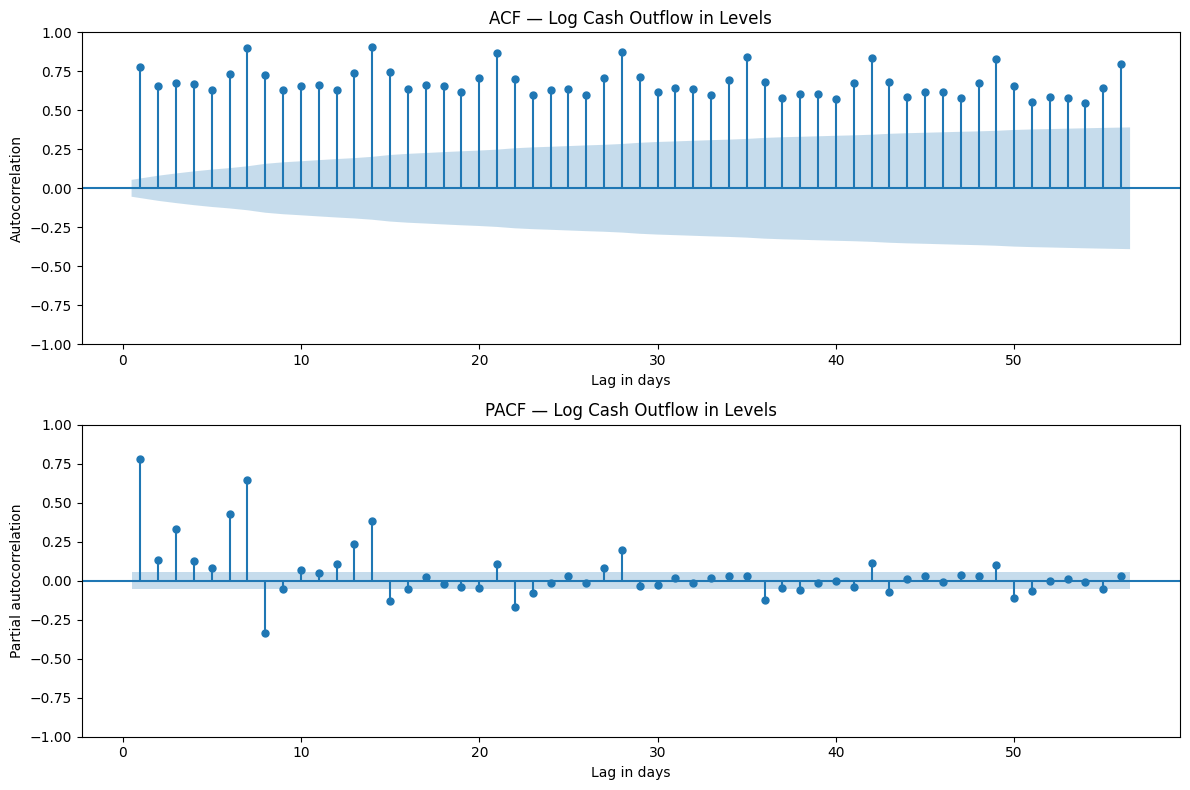

In [106]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
)

plot_acf(
    dependence_series["log_target"],
    lags=MAX_LAGS,
    zero=False,
    ax=axes[0],
)

axes[0].set_title(
    "ACF — Log Cash Outflow in Levels"
)
axes[0].set_xlabel("Lag in days")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(
    dependence_series["log_target"],
    lags=MAX_LAGS,
    zero=False,
    method="ywm",
    ax=axes[1],
)

axes[1].set_title(
    "PACF — Log Cash Outflow in Levels"
)
axes[1].set_xlabel("Lag in days")
axes[1].set_ylabel("Partial autocorrelation")

fig.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_ACF_PACF.png",
    dpi=300,
    bbox_inches="tight",
)

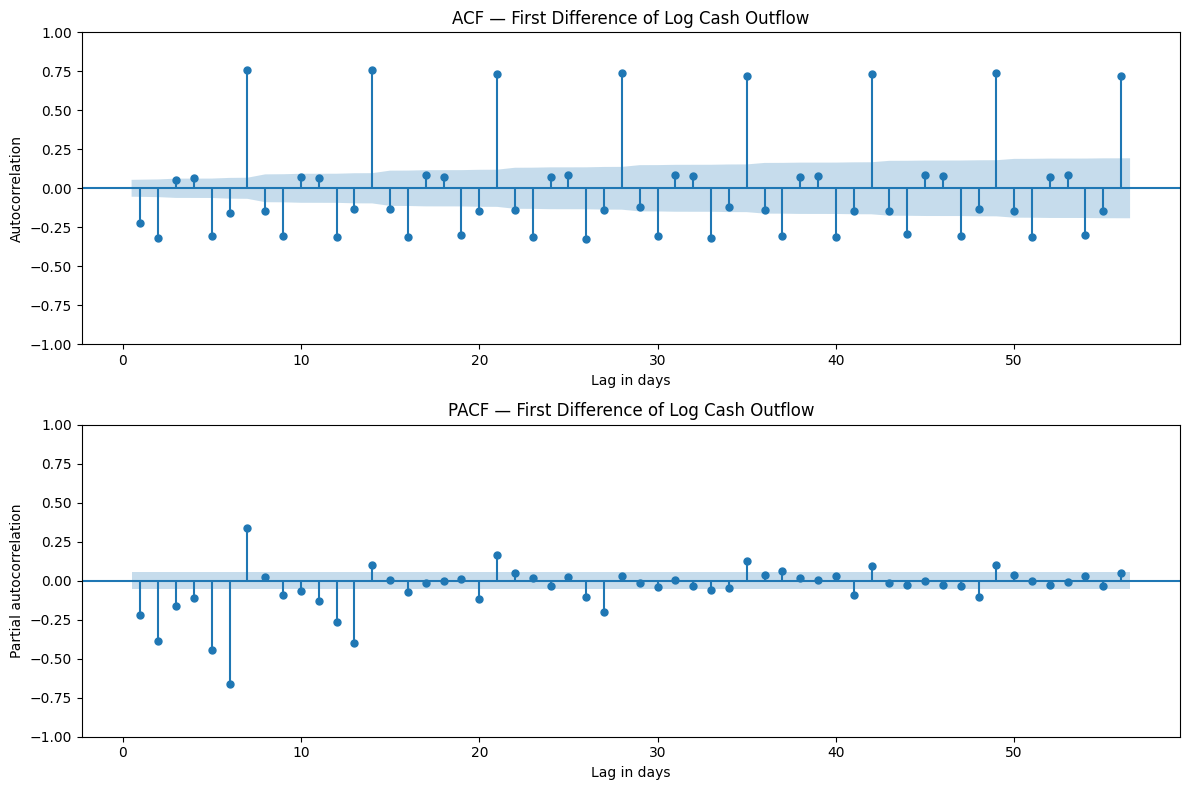

In [111]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
)

plot_acf(
    dependence_series["first_difference"],
    lags=MAX_LAGS,
    zero=False,
    ax=axes[0],
)

axes[0].set_title(
    "ACF — First Difference of Log Cash Outflow"
)
axes[0].set_xlabel("Lag in days")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(
    dependence_series["first_difference"],
    lags=MAX_LAGS,
    zero=False,
    method="ywm",
    ax=axes[1],
)

axes[1].set_title(
    "PACF — First Difference of Log Cash Outflow"
)
axes[1].set_xlabel("Lag in days")
axes[1].set_ylabel("Partial autocorrelation")

fig.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_ACF_PACF_logcash_outflow.png",
    dpi=300,
    bbox_inches="tight",
)

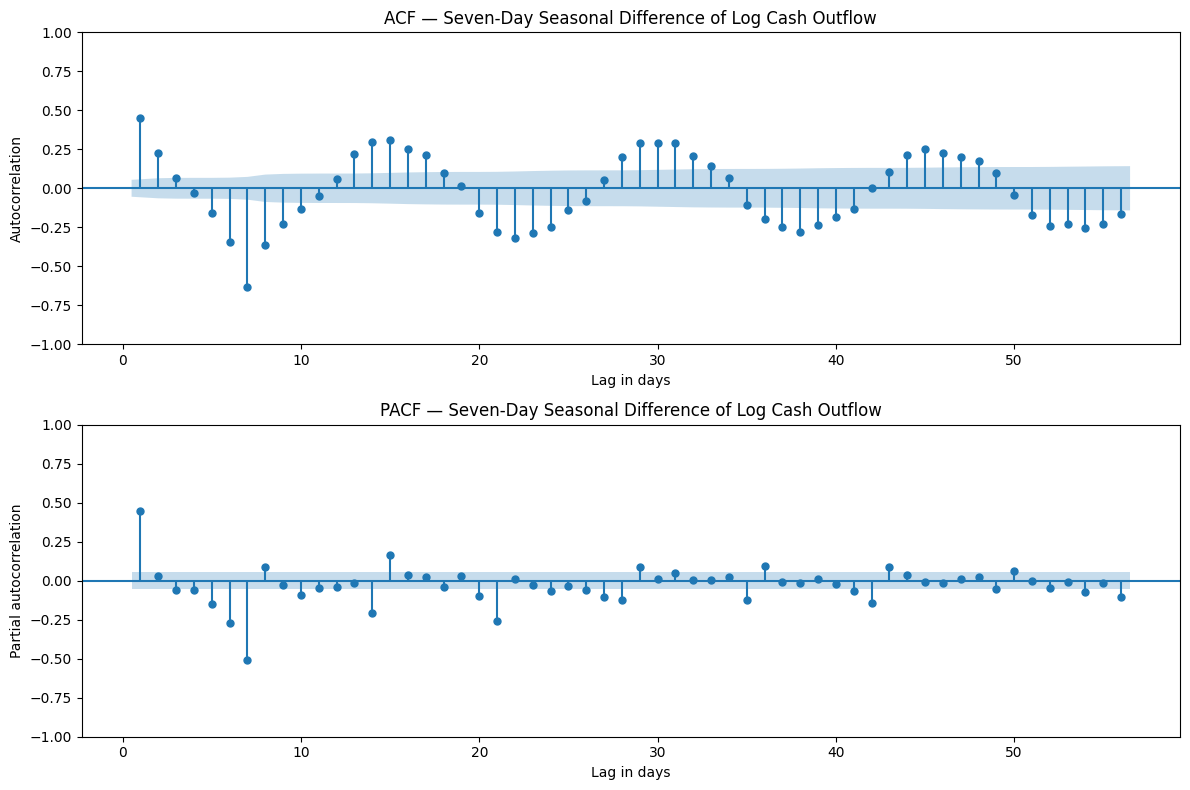

In [112]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
)

plot_acf(
    dependence_series["seasonal_difference_7"],
    lags=MAX_LAGS,
    zero=False,
    ax=axes[0],
)

axes[0].set_title(
    "ACF — Seven-Day Seasonal Difference of Log Cash Outflow"
)
axes[0].set_xlabel("Lag in days")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(
    dependence_series["seasonal_difference_7"],
    lags=MAX_LAGS,
    zero=False,
    method="ywm",
    ax=axes[1],
)

axes[1].set_title(
    "PACF — Seven-Day Seasonal Difference of Log Cash Outflow"
)
axes[1].set_xlabel("Lag in days")
axes[1].set_ylabel("Partial autocorrelation")

fig.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_seven_days_ACF_PACF_logcash_outflow.png",
    dpi=300,
    bbox_inches="tight",
)

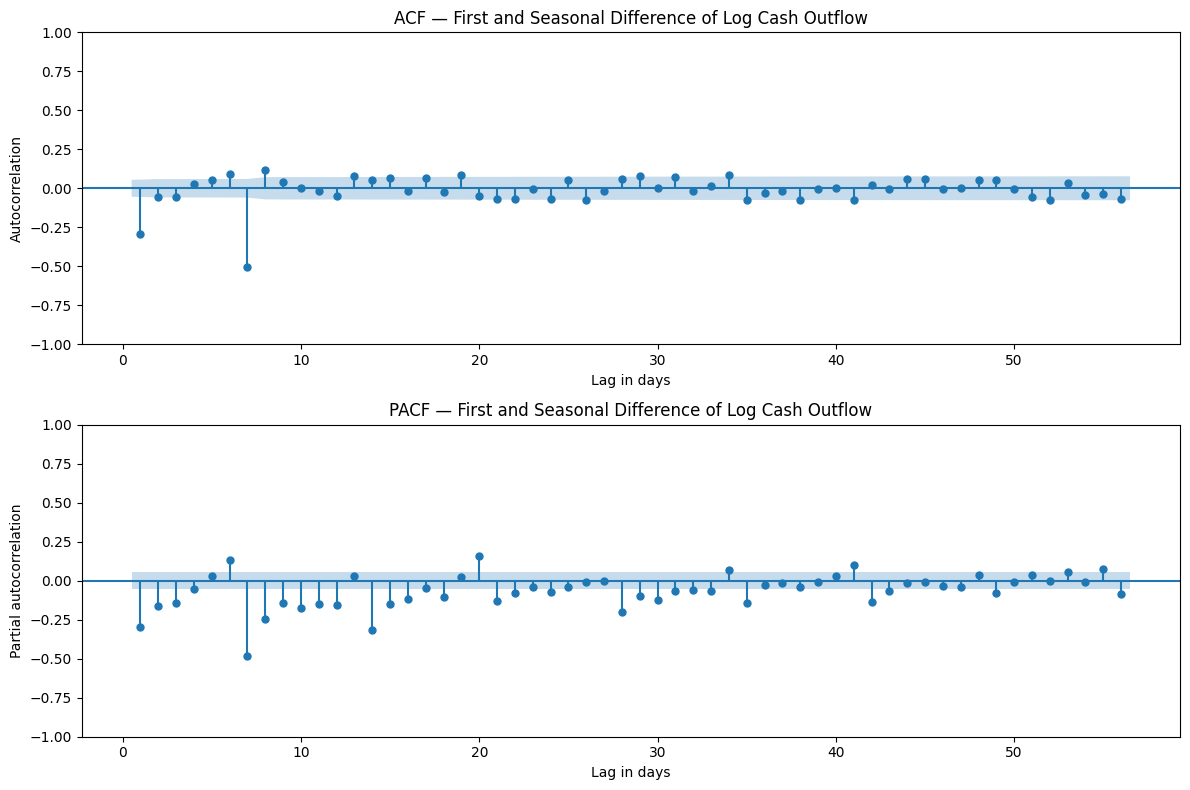

In [113]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
)

plot_acf(
    dependence_series[
        "first_and_seasonal_difference"
    ],
    lags=MAX_LAGS,
    zero=False,
    ax=axes[0],
)

axes[0].set_title(
    "ACF — First and Seasonal Difference of Log Cash Outflow"
)
axes[0].set_xlabel("Lag in days")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(
    dependence_series[
        "first_and_seasonal_difference"
    ],
    lags=MAX_LAGS,
    zero=False,
    method="ywm",
    ax=axes[1],
)

axes[1].set_title(
    "PACF — First and Seasonal Difference of Log Cash Outflow"
)
axes[1].set_xlabel("Lag in days")
axes[1].set_ylabel("Partial autocorrelation")

fig.tight_layout()
plt.show()

fig.savefig(
    FIGURES_DIR / "02_first_and_seasonal_ACF_PACF_logcash_outflow.png",
    dpi=300,
    bbox_inches="tight",
)

### ACF and PACF Findings

The logarithmic target in levels shows strong and persistent autocorrelation,
with particularly large coefficients at weekly lags:

- Lag 7: 0.907.
- Lag 14: 0.931.
- Lag 21: 0.901.
- Lag 28: 0.923.

The first difference substantially reduces the long-term persistence but
preserves strong weekly dependence. Its autocorrelations at lags 7, 14, 21,
and 28 remain between approximately 0.745 and 0.769.

The seven-day seasonal difference reduces the original weekly pattern but
produces a strong negative autocorrelation at lag 7 of -0.635. Applying both
the first and seasonal differences produces negative autocorrelations of
-0.295 at lag 1 and -0.507 at lag 7.

These negative peaks suggest that applying both regular and seasonal
differencing may over-difference the series.

The weekly pattern in this synthetic dataset is primarily deterministic and
associated with day-of-week behavior. Therefore, calendar variables or
explicit seasonal components will initially be preferred over automatically
setting a seasonal integration order of one.

ACF and PACF findings will be combined with ADF and KPSS diagnostics. Final
ARIMA and SARIMAX specifications will be selected through rolling-origin
backtesting and residual analysis.

## ADF and KPSS Stationarity Diagnostics

The Augmented Dickey–Fuller and KPSS tests have complementary null
hypotheses.

### Augmented Dickey–Fuller test

$$
H_0:
\text{the series contains a unit root}
$$

A p-value below 0.05 provides evidence against a unit root.

### KPSS test

$$
H_0:
\text{the series is stationary}
$$

A p-value below 0.05 provides evidence against stationarity.

The tests are applied to:

- The logarithmic target in levels.
- The first logarithmic difference.
- The seven-day seasonal difference.
- The combined first and seasonal difference.
- The STL remainder.

A deterministic trend is included when testing the level series. Differenced
series and the STL remainder are tested around a constant mean.

Stationarity tests are diagnostic tools. They do not determine the final
differencing order independently of autocorrelation patterns, residual
diagnostics, and out-of-sample forecasting performance.

In [110]:
import warnings

from statsmodels.tsa.stattools import adfuller, kpss


def run_stationarity_tests(
    series,
    series_name,
    regression,
    significance_level=0.05,
):
    """
    Run complementary ADF and KPSS stationarity tests.

    Parameters
    ----------
    series : pandas.Series
        Time series to test.
    series_name : str
        Descriptive series name.
    regression : {"c", "ct"}
        Deterministic terms included in the tests.
        "c" includes a constant and "ct" includes a constant and trend.
    significance_level : float
        Threshold used for the test conclusions.

    Returns
    -------
    dict
        Test statistics, p-values, lag choices, and conclusions.
    """
    clean_series = series.dropna().astype(float)

    adf_output = adfuller(
        clean_series,
        regression=regression,
        autolag="AIC",
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        kpss_output = kpss(
            clean_series,
            regression=regression,
            nlags="auto",
        )

    adf_statistic = adf_output[0]
    adf_p_value = adf_output[1]
    adf_lags = adf_output[2]

    kpss_statistic = kpss_output[0]
    kpss_p_value = kpss_output[1]
    kpss_lags = kpss_output[2]

    adf_conclusion = (
        "reject_unit_root"
        if adf_p_value < significance_level
        else "fail_to_reject_unit_root"
    )

    kpss_conclusion = (
        "reject_stationarity"
        if kpss_p_value < significance_level
        else "fail_to_reject_stationarity"
    )

    if (
        adf_p_value < significance_level
        and kpss_p_value >= significance_level
    ):
        combined_diagnosis = "stationary"

    elif (
        adf_p_value >= significance_level
        and kpss_p_value < significance_level
    ):
        combined_diagnosis = "non_stationary"

    else:
        combined_diagnosis = "inconclusive_or_boundary_case"

    return {
        "series": series_name,
        "regression": regression,
        "observations": len(clean_series),
        "adf_statistic": round(adf_statistic, 4),
        "adf_p_value": round(adf_p_value, 4),
        "adf_lags": int(adf_lags),
        "adf_conclusion": adf_conclusion,
        "kpss_statistic": round(kpss_statistic, 4),
        "kpss_p_value": round(kpss_p_value, 4),
        "kpss_lags": int(kpss_lags),
        "kpss_conclusion": kpss_conclusion,
        "combined_diagnosis": combined_diagnosis,
    }

In [45]:
stationarity_test_specs = [
    {
        "series_name": "log_target",
        "series": df["log_target"],
        "regression": "ct",
    },
    {
        "series_name": "first_difference",
        "series": df["log_target_diff_1"],
        "regression": "c",
    },
    {
        "series_name": "seasonal_difference_7",
        "series": df["log_target_diff_7"],
        "regression": "c",
    },
    {
        "series_name": "first_and_seasonal_difference",
        "series": df["log_target_diff_1_7"],
        "regression": "c",
    },
    {
        "series_name": "stl_remainder",
        "series": df["stl_log_remainder"],
        "regression": "c",
    },
]

stationarity_results = pd.DataFrame(
    [
        run_stationarity_tests(
            series=specification["series"],
            series_name=specification["series_name"],
            regression=specification["regression"],
        )
        for specification in stationarity_test_specs
    ]
)

stationarity_results

,series,regression,observations,adf_statistic,adf_p_value,adf_lags,adf_conclusion,kpss_statistic,kpss_p_value,kpss_lags,kpss_conclusion,combined_diagnosis
0,log_target,ct,1308,-4.6367,0.0009,22,reject_unit_root,0.4901,0.01,34,reject_stationarity,inconclusive_or_boundary_case
1,first_difference,c,1307,-11.4882,0.0000,21,reject_unit_root,0.0248,0.10,36,fail_to_reject_stationarity,stationary
2,seasonal_difference_7,c,1301,-12.1942,0.0000,23,reject_unit_root,0.0082,0.10,10,fail_to_reject_stationarity,stationary
3,first_and_seasonal_difference,c,1300,-13.2668,0.0000,23,reject_unit_root,0.0182,0.10,31,fail_to_reject_stationarity,stationary
4,stl_remainder,c,1308,-10.2888,0.0000,22,reject_unit_root,0.0511,0.10,7,fail_to_reject_stationarity,stationary


In [46]:
stationarity_summary = stationarity_results[
    [
        "series",
        "regression",
        "adf_statistic",
        "adf_p_value",
        "adf_conclusion",
        "kpss_statistic",
        "kpss_p_value",
        "kpss_conclusion",
        "combined_diagnosis",
    ]
].copy()

stationarity_summary

,series,regression,adf_statistic,adf_p_value,adf_conclusion,kpss_statistic,kpss_p_value,kpss_conclusion,combined_diagnosis
0,log_target,ct,-4.6367,0.0009,reject_unit_root,0.4901,0.01,reject_stationarity,inconclusive_or_boundary_case
1,first_difference,c,-11.4882,0.0000,reject_unit_root,0.0248,0.10,fail_to_reject_stationarity,stationary
2,seasonal_difference_7,c,-12.1942,0.0000,reject_unit_root,0.0082,0.10,fail_to_reject_stationarity,stationary
3,first_and_seasonal_difference,c,-13.2668,0.0000,reject_unit_root,0.0182,0.10,fail_to_reject_stationarity,stationary
4,stl_remainder,c,-10.2888,0.0000,reject_unit_root,0.0511,0.10,fail_to_reject_stationarity,stationary


### Stationarity Findings

The stationarity diagnostics confirm that the logarithmic target in levels
should not be treated as a stationary time series.

For `log_target`:

- The ADF test rejects the unit-root null hypothesis with a p-value of 0.0009.
- The KPSS test rejects trend stationarity with a p-value of 0.01.
- The combined result is therefore inconclusive.

This conflict is consistent with a series containing a strong nonlinear
trend, weekly seasonality, calendar effects, and occasional extraordinary
events.

The first logarithmic difference is classified as stationary by both tests.
However, its ACF retains strong autocorrelation at weekly lags, indicating
that first differencing removes the long-term trend but not the weekly
seasonal structure.

The seven-day seasonal difference also passes both stationarity tests, but it
produces a strong negative autocorrelation at lag 7. Applying both regular and
seasonal differencing produces negative autocorrelation at lags 1 and 7.
These patterns suggest potential over-differencing.

The STL remainder is stationary according to both tests, supporting the
interpretation that trend and weekly seasonality explain a substantial part
of the original non-stationarity.

The initial modeling strategy will therefore:

- Use the logarithmic target for statistical models.
- Compare models with no regular differencing and one regular difference.
- Represent weekly seasonality initially through calendar regressors or
  explicit seasonal components.
- Avoid setting the seasonal differencing order to one automatically.
- Select the final specification through rolling-origin backtesting and
  residual diagnostics.

In [47]:
eda_decisions = pd.DataFrame(
    [
        {
            "topic": "Target scale",
            "decision": "Use log_target for statistical diagnostics",
            "evidence": (
                "Rolling mean-std correlation decreased "
                "from 0.967 to -0.159 after log transformation"
            ),
            "status": "Validated",
        },
        {
            "topic": "Long-term trend",
            "decision": "Treat the target as strongly trending",
            "evidence": "STL trend strength = 0.908",
            "status": "Validated",
        },
        {
            "topic": "Weekly seasonality",
            "decision": "Use a seven-day seasonal benchmark",
            "evidence": (
                "STL weekly seasonal strength = 0.730; "
                "Friday +21.2%, Sunday -34.2%"
            ),
            "status": "Validated",
        },
        {
            "topic": "Calendar effects",
            "decision": (
                "Include payday-window, month-end, and holiday variables"
            ),
            "evidence": (
                "Payday +28.1%, month-end +17.8%, holiday -12.1%"
            ),
            "status": "Validated",
        },
        {
            "topic": "Extraordinary events",
            "decision": "Preserve and model documented event observations",
            "evidence": (
                "Promotions +14.8%, incidents -25.7%, "
                "merchant settlements +54.4%, macro shocks +20.3%"
            ),
            "status": "Validated",
        },
        {
            "topic": "Extreme observations",
            "decision": "Do not delete adjusted extremes",
            "evidence": (
                "92.3% of high extremes and 69.2% of low extremes "
                "have documented causes"
            ),
            "status": "Validated",
        },
        {
            "topic": "Regular differencing",
            "decision": "Compare d=0 and d=1 specifications",
            "evidence": (
                "First difference is stationary but retains "
                "strong weekly autocorrelation"
            ),
            "status": "Pending backtesting",
        },
        {
            "topic": "Seasonal differencing",
            "decision": "Do not use D=1 automatically",
            "evidence": (
                "Seasonal differencing produces lag-7 "
                "autocorrelation of -0.635"
            ),
            "status": "Active",
        },
    ]
)

eda_decisions

,topic,decision,evidence,status
0,Target scale,Use log_target for statistical diagnostics,Rolling mean-std correlation decreased from 0....,Validated
1,Long-term trend,Treat the target as strongly trending,STL trend strength = 0.908,Validated
2,Weekly seasonality,Use a seven-day seasonal benchmark,STL weekly seasonal strength = 0.730; Friday +...,Validated
3,Calendar effects,"Include payday-window, month-end, and holiday ...","Payday +28.1%, month-end +17.8%, holiday -12.1%",Validated
4,Extraordinary events,Preserve and model documented event observations,"Promotions +14.8%, incidents -25.7%, merchant ...",Validated
5,Extreme observations,Do not delete adjusted extremes,92.3% of high extremes and 69.2% of low extrem...,Validated
6,Regular differencing,Compare d=0 and d=1 specifications,First difference is stationary but retains str...,Pending backtesting
7,Seasonal differencing,Do not use D=1 automatically,Seasonal differencing produces lag-7 autocorre...,Active


In [49]:
# ---------------------------------------------------------
# Save validated EDA summary tables
# ---------------------------------------------------------

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

eda_tables = {
    "02_annual_target_summary.csv": (
        annual_target_summary.reset_index()
    ),
    "02_weekday_seasonality_summary.csv": (
        weekday_seasonality_summary.reset_index()
    ),
    "02_calendar_effect_summary.csv": (
        calendar_effect_summary
    ),
    "02_extraordinary_event_summary.csv": (
        extraordinary_event_summary
    ),
    "02_extreme_observations.csv": (
        extreme_observations
    ),
    "02_stl_weekday_profile.csv": (
        stl_weekday_profile.reset_index()
    ),
    "02_stationarity_results.csv": (
        stationarity_results
    ),
    "02_eda_decisions.csv": (
        eda_decisions
    ),
}

saved_eda_tables = []

for file_name, table in eda_tables.items():
    output_path = DATA_PROCESSED_DIR / file_name

    table.to_csv(
        output_path,
        index=False,
        date_format="%Y-%m-%d",
    )

    saved_eda_tables.append(
        {
            "file": file_name,
            "rows": len(table),
            "columns": len(table.columns),
            "exists": output_path.exists(),
            "size_kb": round(
                output_path.stat().st_size / 1024,
                2,
            ),
        }
    )

saved_eda_tables = pd.DataFrame(saved_eda_tables)

assert saved_eda_tables["exists"].all(), (
    "At least one EDA table was not saved."
)

print(
    "Validated EDA tables saved in:\n"
    f"{DATA_PROCESSED_DIR.resolve()}"
)

saved_eda_tables

Validated EDA tables saved in:
C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed


,file,rows,columns,exists,size_kb
0,02_annual_target_summary.csv,4,9,True,0.33
1,02_weekday_seasonality_summary.csv,7,10,True,0.64
2,02_calendar_effect_summary.csv,5,7,True,0.35
3,02_extraordinary_event_summary.csv,5,10,True,0.48
4,02_extreme_observations.csv,26,12,True,2.40
5,02_stl_weekday_profile.csv,7,7,True,0.47
6,02_stationarity_results.csv,5,12,True,0.72
7,02_eda_decisions.csv,8,4,True,1.10


## Conclusion

This notebook analyzed the temporal structure of the synthetic Fintech
cash-outflow dataset generated in Notebook 01.

The main findings are:

### Trend and variability

- Daily cash outflows exhibit a strong and sustained upward trend.
- Absolute variability increases with the series level.
- The relationship between the 30-day rolling mean and standard deviation is
  0.967 on the original scale.
- Applying the natural logarithm substantially stabilizes the variance.

### Weekly seasonality

The target contains a strong seven-day seasonal pattern:

- Friday is approximately 20–21% above its local seasonal baseline.
- Saturday is approximately 16–17% below the baseline.
- Sunday is approximately 34% below the baseline.
- STL estimates a weekly seasonal strength of 0.730.

This pattern justifies a seasonal naive model with period seven as the main
initial benchmark.

### Calendar effects

After adjusting for trend and weekday behavior:

- Payday-window cash outflows increase by approximately 28%.
- Month-end cash outflows increase by approximately 18%.
- Holiday cash outflows decrease by approximately 12%.

### Extraordinary events

After trend, weekday, and calendar adjustment:

- Promotions increase cash outflows by approximately 15%.
- System incidents reduce cash outflows by approximately 26%.
- Merchant settlements increase cash outflows by approximately 54%.
- Macroeconomic shocks increase cash outflows by approximately 20%.

### Extreme observations

Most adjusted extremes have documented causes. No observations will be
removed, because they represent valid operational conditions or realistic
stochastic variation that forecasting models must capture.

### Decomposition and stationarity

STL identifies:

- Trend strength of 0.908.
- Weekly seasonal strength of 0.730.
- A stationary remainder.

The original logarithmic series should not be treated as stationary in
practice. The first difference is stationary but retains weekly dependence.
Seasonal differencing also produces a stationary series, but introduces a
strong negative autocorrelation at lag 7, suggesting possible
over-differencing.

The preferred initial strategy is therefore to model weekly seasonality
through calendar regressors or explicit seasonal components rather than
automatically applying seasonal differencing.

The dataset passes **Gate 2 — Time-Series EDA** and is ready for benchmark and
ETS modeling in:

`03_baselines_and_ets.ipynb`